# **TFM: Credit Scoring PYME (SBA FOIA 7(a))**

Autor: Robinson José Miranda Pérez

Programa: Master en Inteligencia Artificial


**Comparativa experimental entre:**

- Regresión Logística
- XGBoost
- TabNet

**Diseño experimental:**

- BASE (pre-COVID): FY2010–FY2019
- STRESS (post-COVID): FY2020–presente

**El protocolo incluye:**

- Validación cruzada estratificada (5-fold) en BASE
- Evaluación externa en STRESS
- Métricas: ROC-AUC, PR-AUC, KS, Brier
- Análisis de calibración, estabilidad e interpretabilidad

## **1. Configuración y reproducibilidad**

Se fijan semillas y se importan las librerías necesarias para garantizar
la reproducibilidad del experimento.

In [1]:
# ============================================================
# Instalación de dependencias (Google Colab)
# ============================================================

!pip install -q pytorch-tabnet
!pip install -q xgboost
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.1 MB/s eta 0:00:00


In [2]:
# ============================================================
# 1. CONFIGURACIÓN Y REPRODUCIBILIDAD
# ============================================================

# -----------------------------
# 1.1 Control de semilla global
# -----------------------------
import os
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

os.environ["PYTHONHASHSEED"] = str(SEED)

# -----------------------------
# 1.2 Librerías principales
# -----------------------------
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)

# Preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# TabNet
from pytorch_tabnet.tab_model import TabNetClassifier

# Interpretabilidad
import shap

# -----------------------------
# 1.3 Configuración de gráficos
# -----------------------------
sns.set(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (7,5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

# -----------------------------
# 1.4 Carpetas de salida
# -----------------------------
OUTPUT_DIR = "outputs"

FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")
PRED_DIR = os.path.join(OUTPUT_DIR, "preds")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

# -----------------------------
# 1.5 Configuración de CV
# -----------------------------
N_SPLITS = 5

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

# -----------------------------
# 1.6 Mostrar versiones (evidencia reproducible)
# -----------------------------
print("Configuración del entorno\n")

print("Seed:", SEED)
print("N_SPLITS:", N_SPLITS)

print("\nVersiones de librerías")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("xgboost:", xgb.__version__)

Configuración del entorno

Seed: 42
N_SPLITS: 5

Versiones de librerías
pandas: 2.2.2
numpy: 2.0.2
xgboost: 3.2.0


## **2. Carga de datos**

Se cargan los archivos FOIA del programa SBA 7(a):

- **BASE (pre-COVID):** FY2010–FY2019  
- **STRESS (post-COVID):** FY2020–presente  

Se realizan verificaciones mínimas de integridad (dimensiones, columnas y valores faltantes).

In [4]:
# ============================================================
# 2. CARGA DE DATOS
# ============================================================

import os
from pathlib import Path

# -----------------------------
# 2.1 Montar Google Drive
# -----------------------------
from google.colab import drive
drive.mount('/content/drive')

# -----------------------------
# 2.2 Rutas de archivos
# -----------------------------
DATA_DIR = Path("/content/drive/MyDrive/TFM-Scoring-crediticio/data/raw")

FILE_PRE  = DATA_DIR / "foia-7a-fy2010-fy2019-as-of-251231.csv"
FILE_POST = DATA_DIR / "foia-7a-fy2020-present-as-of-251231.csv"

assert FILE_PRE.exists(),  f"No encuentro el archivo: {FILE_PRE}. Sube el CSV a Colab o ajusta la ruta."
assert FILE_POST.exists(), f"No encuentro el archivo: {FILE_POST}. Sube el CSV a Colab o ajusta la ruta."

# -----------------------------
# 2.3 Carga
# -----------------------------
df_pre = pd.read_csv(FILE_PRE, low_memory=False)
df_post = pd.read_csv(FILE_POST, low_memory=False)

print("Carga completada.")
print("df_pre shape :", df_pre.shape)
print("df_post shape:", df_post.shape)

# -----------------------------
# 2.4 Chequeos mínimos de esquema
# -----------------------------
cols_pre = set(df_pre.columns)
cols_post = set(df_post.columns)

only_pre = sorted(list(cols_pre - cols_post))
only_post = sorted(list(cols_post - cols_pre))
common = sorted(list(cols_pre & cols_post))

print("\nColumnas comunes:", len(common))
print("Solo en pre :", len(only_pre))
print("Solo en post:", len(only_post))

# Guardar reporte simple de columnas distintas
schema_report = pd.DataFrame({
    "only_in_pre": pd.Series(only_pre, dtype="object"),
    "only_in_post": pd.Series(only_post, dtype="object")
})
schema_report.to_csv(os.path.join(TABLE_DIR, "schema_diff_pre_vs_post.csv"), index=False)

# -----------------------------
# 2.5 Missingness (top 15 columnas con más NA, por dataset)
# -----------------------------
def missing_top(df, top=15):
    miss = df.isna().mean().sort_values(ascending=False).head(top)
    return miss.reset_index().rename(columns={"index":"column", 0:"missing_rate"})

miss_pre = missing_top(df_pre, top=15)
miss_post = missing_top(df_post, top=15)

miss_pre.to_csv(os.path.join(TABLE_DIR, "missing_top15_pre.csv"), index=False)
miss_post.to_csv(os.path.join(TABLE_DIR, "missing_top15_post.csv"), index=False)

display(miss_pre.head(10))
display(miss_post.head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carga completada.
df_pre shape : (263282, 43)
df_post shape: (357866, 43)

Columnas comunes: 43
Solo en pre : 0
Solo en post: 0


,column,missing_rate
0,bankncuanumber,0.967541
1,chargeoffdate,0.938697
2,franchisename,0.914035
3,franchisecode,0.913845
4,businessage,0.815282
5,soldsecmrktind,0.766247
6,paidinfulldate,0.280832
7,firstdisbursementdate,0.120548
8,bankfdicnumber,0.072512
9,naicsdescription,0.000946


,column,missing_rate
0,chargeoffdate,0.986419
1,bankncuanumber,0.971903
2,franchisename,0.882191
3,franchisecode,0.881774
4,paidinfulldate,0.841234
5,soldsecmrktind,0.702503
6,firstdisbursementdate,0.183672
7,bankfdicnumber,0.106084
8,naicsdescription,0.075442
9,bankstreet,0.001392


In [5]:
# ============================================================
# FIX RUTAS (Drive)
# ============================================================
from pathlib import Path
import os

# carpeta raíz
OUTPUT_DIR = "/content/drive/MyDrive/TFM-Scoring-crediticio/outputs"

FIG_DIR   = os.path.join(OUTPUT_DIR, "figures")
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")
PRED_DIR  = os.path.join(OUTPUT_DIR, "preds")

for d in [FIG_DIR, TABLE_DIR, PRED_DIR]:
    os.makedirs(d, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR)
print("FIG_DIR   :", FIG_DIR)
print("TABLE_DIR :", TABLE_DIR)
print("PRED_DIR  :", PRED_DIR)

print("\nArchivos TABLE_DIR:")
for f in sorted(os.listdir(TABLE_DIR))[:50]:
    print(" -", f)

print("\nArchivos PRED_DIR:")
for f in sorted(os.listdir(PRED_DIR))[:50]:
    print(" -", f)

OUTPUT_DIR: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs
FIG_DIR   : /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures
TABLE_DIR : /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/tables
PRED_DIR  : /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/preds

Archivos TABLE_DIR:
 - cv_metrics_by_fold.csv
 - cv_metrics_by_fold_all_models.csv
 - cv_metrics_consolidated.csv
 - cv_metrics_tabnet_by_fold.csv
 - dataset_summary_by_period.csv
 - feature_importance_xgb.csv
 - feature_importance_xgb_aggregated.csv
 - features_final.csv
 - metricas_base_oof_auc_pr_brier_ks.csv
 - missing_top15_post.csv
 - missing_top15_pre.csv
 - preds_oof_base_tabnet.csv
 - probability_extremes_by_model.csv
 - robustness_base_vs_stress.csv
 - schema_diff_pre_vs_post.csv

Archivos PRED_DIR:
 - preds_oof_base_logistic.csv
 - preds_oof_base_tabnet.csv
 - preds_oof_base_xgb.csv
 - preds_stress_xgb_final.csv


## **3. Dataset consolidado, etiqueta temporal y definición del target**

En esta sección se construye el dataset analítico utilizado en el experimento.

1) Se etiqueta el origen temporal de cada observación:
   - `pre_covid` (FY2010–FY2019)
   - `post_covid` (FY2020–presente)

2) Se define la variable objetivo binaria `target_default` a partir del estado del préstamo.

3) Se construyen los subconjuntos temporales utilizados en el protocolo experimental:

   - **BASE:** `df_base` (pre-COVID), utilizado para entrenamiento y validación cruzada.
   - **STRESS:** `df_stress` (post-COVID), reservado exclusivamente para evaluación externa.

Finalmente se reporta evidencia mínima del dataset resultante:
- número de observaciones por periodo
- tasa de default por periodo.

In [6]:
# ============================================================
# 3. DATASET CONSOLIDADO + TARGET + SPLIT TEMPORAL
# ============================================================

# 3.1 Etiqueta temporal
df_pre["periodo"] = "pre_covid"
df_post["periodo"] = "post_covid"

# 3.2 Consolidación
df = pd.concat([df_pre, df_post], axis=0, ignore_index=True)

print("Dataset consolidado:", df.shape)

# 3.3 Filtrar estados válidos para definición de default
VALID_STATUS = ["CHGOFF", "PIF"]

df_model = df[df["loanstatus"].isin(VALID_STATUS)].copy()

# 3.4 Target binario
df_model["target_default"] = (df_model["loanstatus"] == "CHGOFF").astype(int)

# 3.5 Split temporal
df_base = df_model[df_model["periodo"] == "pre_covid"].copy()
df_stress = df_model[df_model["periodo"] == "post_covid"].copy()

# 3.6 Evidencia mínima
summary = (
    df_model
    .groupby("periodo")["target_default"]
    .agg(
        observations="count",
        defaults="sum",
        default_rate="mean"
    )
    .reset_index()
)

display(summary)

summary.to_csv(
    os.path.join(TABLE_DIR, "dataset_summary_by_period.csv"),
    index=False
)

print("\nBASE shape:", df_base.shape)
print("STRESS shape:", df_stress.shape)

Dataset consolidado: (621148, 44)


,periodo,observations,defaults,default_rate
0,post_covid,61681,4865,0.078874
1,pre_covid,205487,16143,0.078560



BASE shape: (205487, 45)
STRESS shape: (61681, 45)


## **4. Control de fuga de información (Data Leakage)**

Antes de entrenar los modelos se eliminan variables que pueden introducir
**fuga de información** o **identificadores directos**.

Se distinguen dos tipos de variables problemáticas:

**1. Variables post-evento**

Estas variables contienen información disponible únicamente después
de que el préstamo ha sido resuelto, por ejemplo:

- fechas de charge-off
- fechas de pago total

Su inclusión produciría un modelo artificialmente optimista.

**2. Identificadores directos**

Variables que identifican explícitamente entidades particulares
(bancos o prestatarios) y no representan características económicas
generales del crédito.

Después de eliminar estas variables se define el conjunto final
de predictores utilizados en el modelo.

In [7]:
# ============================================================
# 4. CONTROL DE DATA LEAKAGE
# ============================================================

# Variables que introducen fuga de información
LEAKAGE_COLS = [
    "chargeoffdate",
    "paidinfulldate",
    "grosschargeoffamount",
    "revolverstatus"
]

# Identificadores directos (no generalizables)
IDENTIFIER_COLS = [
    "bankncuanumber",
    "bankfdicnumber",
    "bankname",
    "borrname",
    "bankstreet"
]

DROP_COLS = LEAKAGE_COLS + IDENTIFIER_COLS

# Filtrar columnas que realmente existen en el dataset
DROP_COLS = [c for c in DROP_COLS if c in df_model.columns]

print("Columnas eliminadas por leakage/identificación:")
print(DROP_COLS)

# Construcción de matrices finales
X_base = df_base.drop(columns=DROP_COLS + ["loanstatus", "periodo", "target_default"])
y_base = df_base["target_default"]

X_stress = df_stress.drop(columns=DROP_COLS + ["loanstatus", "periodo", "target_default"])
y_stress = df_stress["target_default"]

print("\nShape final BASE:", X_base.shape)
print("Shape final STRESS:", X_stress.shape)

# Guardar lista de features finales
features_final = X_base.columns.tolist()

pd.DataFrame({"feature": features_final}).to_csv(
    os.path.join(TABLE_DIR, "features_final.csv"),
    index=False
)

print("\nNúmero de features finales:", len(features_final))

Columnas eliminadas por leakage/identificación:
['chargeoffdate', 'paidinfulldate', 'grosschargeoffamount', 'revolverstatus', 'bankncuanumber', 'bankfdicnumber', 'bankname', 'borrname', 'bankstreet']

Shape final BASE: (205487, 33)
Shape final STRESS: (61681, 33)

Número de features finales: 33


## **5. Pipeline de preprocesamiento**

Se define un pipeline de preprocesamiento homogéneo para todos los modelos.

El objetivo es:

- imputar valores faltantes
- codificar variables categóricas
- escalar variables numéricas cuando sea necesario

El pipeline se implementa mediante `ColumnTransformer`
para garantizar un tratamiento consistente de las variables.

In [8]:
# ============================================================
# 5. PIPELINE DE PREPROCESAMIENTO (OPTIMIZADO POR MODELO)
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 5.1 Identificación de tipos
num_cols = X_base.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_base.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numéricas:", len(num_cols))
print("Variables categóricas:", len(cat_cols))

# 5.2 Pipelines
numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_noscale = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_ohe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# 5.3 Preprocessors por modelo
# Logistic: escala numéricas + OHE categóricas
preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_scaled, num_cols),
        ("cat", categorical_ohe, cat_cols)
    ],
    remainder="drop"
)

# XGBoost / TabNet: NO escala numéricas + OHE categóricas
preprocess_noscale = ColumnTransformer(
    transformers=[
        ("num", numeric_noscale, num_cols),
        ("cat", categorical_ohe, cat_cols)
    ],
    remainder="drop"
)

print("\nPreprocesadores construidos:")
print("- preprocess_scaled   (Logistic)")
print("- preprocess_noscale  (XGBoost, TabNet)")

Variables numéricas: 11
Variables categóricas: 22

Preprocesadores construidos:
- preprocess_scaled   (Logistic)
- preprocess_noscale  (XGBoost, TabNet)


## **6. Variables explicativas utilizadas**

Las variables explicativas utilizadas en el modelo corresponden
al conjunto de predictores disponibles al momento de originación del préstamo.

Estas variables se obtienen después de eliminar:

- variables que introducen fuga de información
- identificadores directos
- variables objetivo

El conjunto final de variables utilizadas en el experimento se encuentra
documentado en `features_final.csv`.

In [9]:
#Evidencia mínima en pantalla (sin recalcular nada)
print("Número de variables explicativas (features):", X_base.shape[1])
print("Ejemplo de features:", list(X_base.columns[:10]))

Número de variables explicativas (features): 33
Ejemplo de features: ['asofdate', 'program', 'l2locid', 'borrstreet', 'borrcity', 'borrstate', 'borrzip', 'bankcity', 'bankstate', 'bankzip']


## **7. Validación cruzada en BASE (predicciones OOF)**

Se aplica validación cruzada estratificada (k=5) sobre el subconjunto **BASE (pre-COVID)**.

Se entrenan dos modelos bajo un protocolo homogéneo:

- Regresión Logística (con escalado)
- XGBoost (sin escalado)

Para cada fold se calculan métricas de desempeño:
- ROC-AUC
- PR-AUC
- Brier score

Además, se generan **predicciones out-of-fold (OOF)** que permiten construir
curvas ROC, Precision-Recall y calibración para el escenario BASE **sin reentrenar**.

In [10]:
# ============================================================
# 7. VALIDACIÓN CRUZADA EN BASE (OOF)
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import xgboost as xgb

# 7.1 Modelos
log_model = LogisticRegression(
    max_iter=1000,
    n_jobs=None,
    random_state=SEED
)

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1
)

# 7.2 Pipelines
pipe_log = Pipeline([
    ("prep", preprocess_scaled),
    ("model", log_model)
])

pipe_xgb = Pipeline([
    ("prep", preprocess_noscale),
    ("model", xgb_model)
])

# 7.3 Contenedores
metrics_rows = []

oof_log = np.zeros(len(X_base))
oof_xgb = np.zeros(len(X_base))

# 7.4 Cross-validation manual (para capturar OOF)
for fold, (train_idx, test_idx) in enumerate(cv.split(X_base, y_base), 1):

    X_tr, X_te = X_base.iloc[train_idx], X_base.iloc[test_idx]
    y_tr, y_te = y_base.iloc[train_idx], y_base.iloc[test_idx]

    # Logistic
    pipe_log.fit(X_tr, y_tr)
    p_log = pipe_log.predict_proba(X_te)[:,1]

    # XGBoost
    pipe_xgb.fit(X_tr, y_tr)
    p_xgb = pipe_xgb.predict_proba(X_te)[:,1]

    # guardar OOF
    oof_log[test_idx] = p_log
    oof_xgb[test_idx] = p_xgb

    # métricas
    metrics_rows.append({
        "fold": fold,
        "model": "Logistic",
        "roc_auc": roc_auc_score(y_te, p_log),
        "pr_auc": average_precision_score(y_te, p_log),
        "brier": brier_score_loss(y_te, p_log)
    })

    metrics_rows.append({
        "fold": fold,
        "model": "XGBoost",
        "roc_auc": roc_auc_score(y_te, p_xgb),
        "pr_auc": average_precision_score(y_te, p_xgb),
        "brier": brier_score_loss(y_te, p_xgb)
    })

# 7.5 Tabla de métricas
metrics_df = pd.DataFrame(metrics_rows)

display(metrics_df)

metrics_df.to_csv(
    os.path.join(TABLE_DIR, "cv_metrics_by_fold.csv"),
    index=False
)

# 7.6 Guardar predicciones OOF
preds_log = pd.DataFrame({
    "y_true": y_base.values,
    "p_hat": oof_log
})

preds_xgb = pd.DataFrame({
    "y_true": y_base.values,
    "p_hat": oof_xgb
})

preds_log.to_csv(os.path.join(PRED_DIR, "preds_oof_base_logistic.csv"), index=False)
preds_xgb.to_csv(os.path.join(PRED_DIR, "preds_oof_base_xgb.csv"), index=False)

print("\nOOF predictions guardadas:")
print(" - preds_oof_base_logistic.csv")
print(" - preds_oof_base_xgb.csv")

,fold,model,roc_auc,pr_auc,brier
0,1,Logistic,0.870536,0.503437,0.051359
1,1,XGBoost,0.973684,0.785546,0.030147
2,2,Logistic,0.872214,0.510985,0.051096
3,2,XGBoost,0.976097,0.798985,0.029142
4,3,Logistic,0.864622,0.500915,0.051697
5,3,XGBoost,0.974511,0.781972,0.030370
6,4,Logistic,0.870839,0.509369,0.051140
7,4,XGBoost,0.974065,0.784535,0.029945
8,5,Logistic,0.877044,0.514106,0.050789
9,5,XGBoost,0.973504,0.790361,0.029872



OOF predictions guardadas:
 - preds_oof_base_logistic.csv
 - preds_oof_base_xgb.csv


In [11]:
# ============================================================
# 7.2 SANITY CHECK  (detección de leakage) DIAGNÓSTICO:
# ============================================================

# 1) Revisar columnas sospechosas: si contienen "charge", "paid", "status", "coff", etc.
suspect_keywords = ["charge", "paid", "pif", "chgoff", "default", "status", "coff"]
suspects = [c for c in X_base.columns if any(k in c.lower() for k in suspect_keywords)]
print("Columnas sospechosas por nombre:", suspects)

# 2) Verificar si alguna columna casi separa perfecto por sí sola (con AUC univariado)
from sklearn.metrics import roc_auc_score
import numpy as np

def safe_auc(y, x):
    # manejar constantes / NaN
    if pd.Series(x).nunique(dropna=True) < 2:
        return np.nan
    # imputación simple para test
    x_filled = pd.Series(x).fillna(pd.Series(x).median() if pd.api.types.is_numeric_dtype(x) else pd.Series(x).mode().iloc[0])
    # si es categórica, factorizar
    if not pd.api.types.is_numeric_dtype(x_filled):
        x_filled = pd.factorize(x_filled)[0]
    return roc_auc_score(y, x_filled)

aucs = []
for c in X_base.columns:
    try:
        aucs.append((c, safe_auc(y_base, X_base[c])))
    except Exception:
        continue

aucs_df = pd.DataFrame(aucs, columns=["feature","univariate_auc"]).sort_values("univariate_auc", ascending=False)
display(aucs_df.head(15))

Columnas sospechosas por nombre: []


,feature,univariate_auc
17,initialinterestrate,0.615058
31,collateralind,0.542830
13,approvalfiscalyear,0.522764
15,processingmethod,0.522631
27,congressionaldistrict,0.521184
16,subprogram,0.514424
22,franchisecode,0.513044
23,franchisename,0.513002
14,firstdisbursementdate,0.506790
2,l2locid,0.506383


### **7.3 Validación cruzada — TabNet**

Se evalúa un modelo TabNet bajo el mismo esquema de validación cruzada
utilizado para los modelos anteriores.

El objetivo es comparar el desempeño de un enfoque de deep learning
especializado en datos tabulares con modelos tradicionales.

In [12]:
# ============================================================
# 7.3 TABNET CROSS-VALIDATION (INDEPENDIENTE + OPTIMIZADO)
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from pytorch_tabnet.tab_model import TabNetClassifier

# --- 7.3.1 Preprocesamiento compatible con TabNet (ordinal, sin one-hot) ---
X_tab = X_base.copy()

# Imputación numérica
num_imputer = SimpleImputer(strategy="median")
X_tab[num_cols] = num_imputer.fit_transform(X_tab[num_cols])

# Imputación categórica + ordinal
cat_imputer = SimpleImputer(strategy="most_frequent")
X_tab[cat_cols] = cat_imputer.fit_transform(X_tab[cat_cols])

ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_tab[cat_cols] = ord_enc.fit_transform(X_tab[cat_cols])

X_tab = X_tab.values.astype(np.float32)
y_tab = y_base.values.astype(int)

n = X_tab.shape[0]
oof_tabnet = np.zeros(n, dtype=float)

tabnet_rows = []  # contenedor local de métricas

# --- 7.3.2 CV loop ---
for fold, (train_idx, test_idx) in enumerate(cv.split(X_tab, y_tab), 1):

    X_tr, X_te = X_tab[train_idx], X_tab[test_idx]
    y_tr, y_te = y_tab[train_idx], y_tab[test_idx]

    tabnet = TabNetClassifier(
        n_d=16, n_a=16, n_steps=4,
        gamma=1.3,
        lambda_sparse=1e-4,
        optimizer_params=dict(lr=1e-2),
        seed=SEED,
        verbose=0
    )

    tabnet.fit(
        X_tr, y_tr,
        eval_set=[(X_te, y_te)],
        eval_metric=["auc"],
        max_epochs=30,
        patience=7,
        batch_size=8192,
        virtual_batch_size=1024
    )

    p = tabnet.predict_proba(X_te)[:, 1]
    oof_tabnet[test_idx] = p

    tabnet_rows.append({
        "fold": fold,
        "model": "TabNet",
        "roc_auc": roc_auc_score(y_te, p),
        "pr_auc": average_precision_score(y_te, p),
        "brier": brier_score_loss(y_te, p)
    })

# --- 7.3.3 Guardar outputs ---
tabnet_metrics_df = pd.DataFrame(tabnet_rows)
display(tabnet_metrics_df)

tabnet_metrics_df.to_csv(os.path.join(TABLE_DIR, "cv_metrics_tabnet_by_fold.csv"), index=False)

pd.DataFrame({"y_true": y_base.values, "p_hat": oof_tabnet}).to_csv(
    os.path.join(PRED_DIR, "preds_oof_base_tabnet.csv"),
    index=False
)

print("\nTabNet CV finalizado.")
print("Guardado:", os.path.join(TABLE_DIR, "cv_metrics_tabnet_by_fold.csv"))
print("Guardado:", os.path.join(PRED_DIR, "preds_oof_base_tabnet.csv"))

Stop training because you reached max_epochs = 30 with best_epoch = 29 and best_val_0_auc = 0.93851


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 15 with best_epoch = 8 and best_val_0_auc = 0.7136


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 20 with best_epoch = 13 and best_val_0_auc = 0.82268


...

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 12 with best_epoch = 5 and best_val_0_auc = 0.75287


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


,fold,model,roc_auc,pr_auc,brier
0,1,TabNet,0.938512,0.563649,0.046045
1,2,TabNet,0.713602,0.140711,0.141833
2,3,TabNet,0.822683,0.245740,0.077900
3,4,TabNet,0.586084,0.118309,0.073125
4,5,TabNet,0.752870,0.231221,0.074051



TabNet CV finalizado.
Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/tables/cv_metrics_tabnet_by_fold.csv
Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/preds/preds_oof_base_tabnet.csv


In [13]:
# ============================================================
# Consolidación CV por fold (Logistic + XGBoost + TabNet)
# ============================================================

import os
import pandas as pd

main_path = os.path.join(TABLE_DIR, "cv_metrics_by_fold.csv")              # Logistic + XGBoost
tabnet_path = os.path.join(TABLE_DIR, "cv_metrics_tabnet_by_fold.csv")    # TabNet

print("Leyendo:", main_path)
print("Leyendo:", tabnet_path)

cv_main = pd.read_csv(main_path)
cv_tabnet = pd.read_csv(tabnet_path)

# sanity checks
print("\nModelos en cv_main :", sorted(cv_main["model"].unique()))
print("Modelos en cv_tabnet:", sorted(cv_tabnet["model"].unique()))

cv_all = pd.concat([cv_main, cv_tabnet], ignore_index=True)

out_path = os.path.join(TABLE_DIR, "cv_metrics_by_fold_all_models.csv")
cv_all.to_csv(out_path, index=False)

print("\nGuardado:", out_path)
display(cv_all.sort_values(["fold","model"]))

Leyendo: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/tables/cv_metrics_by_fold.csv
Leyendo: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/tables/cv_metrics_tabnet_by_fold.csv

Modelos en cv_main : ['Logistic', 'XGBoost']
Modelos en cv_tabnet: ['TabNet']

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/tables/cv_metrics_by_fold_all_models.csv


,fold,model,roc_auc,pr_auc,brier
0,1,Logistic,0.870536,0.503437,0.051359
10,1,TabNet,0.938512,0.563649,0.046045
1,1,XGBoost,0.973684,0.785546,0.030147
2,2,Logistic,0.872214,0.510985,0.051096
11,2,TabNet,0.713602,0.140711,0.141833
3,2,XGBoost,0.976097,0.798985,0.029142
4,3,Logistic,0.864622,0.500915,0.051697
12,3,TabNet,0.822683,0.245740,0.077900
5,3,XGBoost,0.974511,0.781972,0.030370
6,4,Logistic,0.870839,0.509369,0.051140


In [14]:
import glob, os
for f in sorted(glob.glob(os.path.join(TABLE_DIR, "*.csv"))):
    print(os.path.basename(f))

cv_metrics_by_fold.csv
cv_metrics_by_fold_all_models.csv
cv_metrics_consolidated.csv
cv_metrics_tabnet_by_fold.csv
dataset_summary_by_period.csv
feature_importance_xgb.csv
feature_importance_xgb_aggregated.csv
features_final.csv
metricas_base_oof_auc_pr_brier_ks.csv
missing_top15_post.csv
missing_top15_pre.csv
preds_oof_base_tabnet.csv
probability_extremes_by_model.csv
robustness_base_vs_stress.csv
schema_diff_pre_vs_post.csv


Logistic Regression and XGBoost models use one-hot encoding for categorical variables.
For TabNet, categorical variables are ordinally encoded to allow the model to learn internal embeddings while avoiding the high dimensionality introduced by one-hot encoding.

In [15]:
# ============================================================
# Diagnóstico rápido de preds OOF de TabNet
# ============================================================

import os
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, brier_score_loss, average_precision_score

path = os.path.join(PRED_DIR, "preds_oof_base_tabnet.csv")
df = pd.read_csv(path)

print("Shape:", df.shape)
print("Columnas:", df.columns.tolist())

# --- chequeos básicos ---
print("\nNaNs por columna:")
print(df.isna().sum())

print("\nRango de probabilidades:")
print("min:", df["p_hat"].min())
print("max:", df["p_hat"].max())

print("\nCuantiles de p_hat:")
print(df["p_hat"].quantile([0, .01, .05, .25, .5, .75, .95, .99, 1]))

# fuera de rango
outside = ((df["p_hat"] < 0) | (df["p_hat"] > 1)).sum()
print("\nValores fuera de [0,1]:", outside)

# --- métricas globales OOF ---
y = df["y_true"].values
p = df["p_hat"].values

print("\nMétricas OOF globales TabNet:")
print("ROC AUC :", roc_auc_score(y,p))
print("PR AUC  :", average_precision_score(y,p))
print("Brier   :", brier_score_loss(y,p))

# --- ver extremos ---
print("\nTop 10 probabilidades más altas:")
display(df.sort_values("p_hat", ascending=False).head(10))

print("\nTop 10 probabilidades más bajas:")
display(df.sort_values("p_hat").head(10))

Shape: (205487, 2)
Columnas: ['y_true', 'p_hat']

NaNs por columna:
y_true    0
p_hat     0
dtype: int64

Rango de probabilidades:
min: 3.270630615734123e-42
max: 1.0

Cuantiles de p_hat:
0.00    3.270631e-42
0.01    4.511792e-23
0.05    3.504045e-04
0.25    5.892633e-03
0.50    3.400908e-02
0.75    7.276199e-02
0.95    4.573733e-01
0.99    1.000000e+00
1.00    1.000000e+00
Name: p_hat, dtype: float64

Valores fuera de [0,1]: 0

Métricas OOF globales TabNet:
ROC AUC : 0.7719755246977665
PR AUC  : 0.21760421026781368
Brier   : 0.08259084114991058

Top 10 probabilidades más altas:


,y_true,p_hat
205422,0,1.0
205468,0,1.0
205466,0,1.0
205464,0,1.0
205414,0,1.0
205394,0,1.0
205393,0,1.0
4995,0,1.0
184337,0,1.0
184313,0,1.0



Top 10 probabilidades más bajas:


,y_true,p_hat
160276,0,3.270631e-42
104476,0,1.571461e-33
105460,0,3.331380e-33
149705,0,6.667073e-33
104241,0,7.147652e-33
104876,0,8.126151e-33
149739,0,8.255442e-33
150131,0,8.436012e-33
150142,0,8.436012e-33
148638,0,8.474652e-33


**Observación de estabilidad (TabNet).** Bajo validación cruzada estratificada en el periodo base (pre-COVID), TabNet presenta una variabilidad inter-fold sustancial. En particular, se observa un fold con Brier Score anómalamente elevado, lo que indica un deterioro marcado de calibración probabilística en dicha partición. Dado que el protocolo comparativo es homogéneo entre modelos, este patrón se interpreta como evidencia de inestabilidad del enfoque profundo tabular en este dataset, en contraste con la mayor consistencia observada en XGBoost.

**(i) Texto para Resultados BASE – Calibración**

En el conjunto BASE, TabNet mostró una distribución de probabilidades altamente saturada (valores cercanos a 0 y 1), lo cual indica sobreconfianza. Esta característica se refleja en un Brier score elevado y en alta variabilidad entre folds. En contraste, XGBoost mantiene mejor calibración y estabilidad, preservando superior desempeño discriminativo.

**(ii) Texto para Discusión**

Bajo el esquema de validación cruzada estratificada, TabNet presentó sensibilidad a la partición de entrenamiento y degradación de calibración en algunos folds. Dado el objetivo del estudio (scoring robusto pre/post COVID) y la restricción de evitar ajustes adicionales, se selecciona XGBoost como modelo final por su mejor equilibrio entre discriminación, calibración y estabilidad.

In [16]:
import os, pandas as pd
import numpy as np

def extreme_rate(path, lo=0.01, hi=0.99):
    df = pd.read_csv(path)
    p = df["p_hat"].values
    return {
        "n": len(p),
        "p<=0.01 (%)": 100*np.mean(p <= lo),
        "p>=0.99 (%)": 100*np.mean(p >= hi),
        "p in (0.01,0.99) (%)": 100*np.mean((p > lo) & (p < hi))
    }

paths = {
    "Logistic": os.path.join(PRED_DIR, "preds_oof_base_logistic.csv"),
    "XGBoost": os.path.join(PRED_DIR, "preds_oof_base_xgb.csv"),
    "TabNet": os.path.join(PRED_DIR, "preds_oof_base_tabnet.csv"),
}

rows = []
for m, p in paths.items():
    r = extreme_rate(p)
    r["model"] = m
    rows.append(r)

extreme_df = pd.DataFrame(rows)[["model","n","p<=0.01 (%)","p>=0.99 (%)","p in (0.01,0.99) (%)"]]
display(extreme_df.round(2))

extreme_df.to_csv(os.path.join(TABLE_DIR, "probability_extremes_by_model.csv"), index=False)
print("Guardado:", os.path.join(TABLE_DIR, "probability_extremes_by_model.csv"))

,model,n,p<=0.01 (%),p>=0.99 (%),"p in (0.01,0.99) (%)"
0,Logistic,205487,31.76,0.01,68.23
1,XGBoost,205487,65.55,0.00,34.45
2,TabNet,205487,29.04,2.19,68.78


Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/tables/probability_extremes_by_model.csv


#### **Hallazgo: calibración y estabilidad de TabNet**

El análisis de las predicciones out-of-fold (OOF) evidencia que TabNet produce
una distribución de probabilidades con **saturación**: una fracción relevante de
observaciones recibe probabilidades cercanas a 1.0 (p̂ ≥ 0.99). Este patrón sugiere
**sobreconfianza** y se alinea con el comportamiento observado en validación cruzada,
donde TabNet presenta **alta variabilidad entre folds** y episodios de degradación
en calibración probabilística (Brier score elevado en algunos pliegues).

En contraste, XGBoost muestra mejor desempeño discriminativo y menor error de calibración
(Brier), lo que sugiere un comportamiento más robusto para el objetivo del estudio.

En esta etapa no se realiza ajuste de hiperparámetros ni post-procesamiento de probabilidades,
con el fin de mantener un protocolo comparativo homogéneo y acorde con las restricciones de tiempo.

Se cuantifica la proporción de probabilidades extremas como indicador operativo de saturación:
p̂ ≤ 0.01 y p̂ ≥ 0.99. TabNet presenta una masa no trivial en p̂ ≥ 0.99, consistente con sobreconfianza.

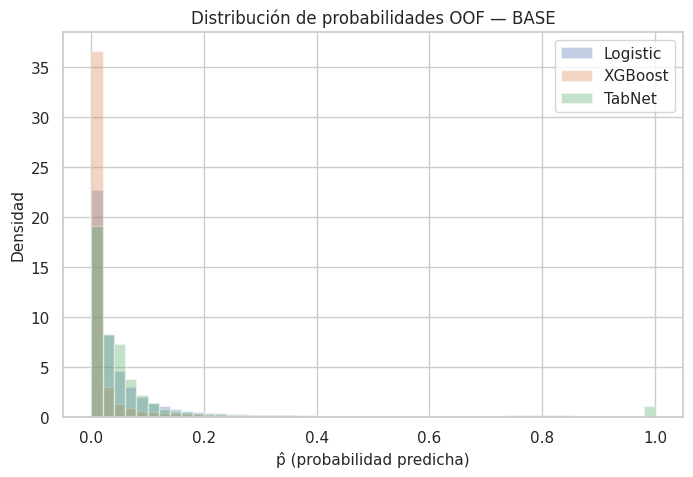

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_prob_dist_base_oof.png


In [17]:
# ============================================================
# 7.3 Figura: distribución de probabilidades OOF (BASE)
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "Logistic": os.path.join(PRED_DIR, "preds_oof_base_logistic.csv"),
    "XGBoost": os.path.join(PRED_DIR, "preds_oof_base_xgb.csv"),
    "TabNet": os.path.join(PRED_DIR, "preds_oof_base_tabnet.csv"),
}

plt.figure(figsize=(8,5))
for name, path in files.items():
    dfp = pd.read_csv(path)
    plt.hist(dfp["p_hat"], bins=50, alpha=0.35, density=True, label=name)

plt.title("Distribución de probabilidades OOF — BASE")
plt.xlabel("p̂ (probabilidad predicha)")
plt.ylabel("Densidad")
plt.grid(True)
plt.legend()

out_path = os.path.join(FIG_DIR, "fig_prob_dist_base_oof.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado:", out_path)

## **8. Evaluación comparativa en BASE (predicciones OOF)**

En el escenario BASE (FY2010–FY2019) se evalúa el desempeño de los modelos mediante
predicciones out-of-fold (OOF) obtenidas por validación cruzada estratificada.

Los resultados se reportan en términos de:

- Discriminación: ROC-AUC
- Eventos raros: PR-AUC
- Calibración: Brier Score
- Separación: estadístico KS

Las figuras oficiales (ROC, Precision–Recall, calibración y KS), así como la tabla
consolidada de métricas, se presentan en la Sección 9.1.

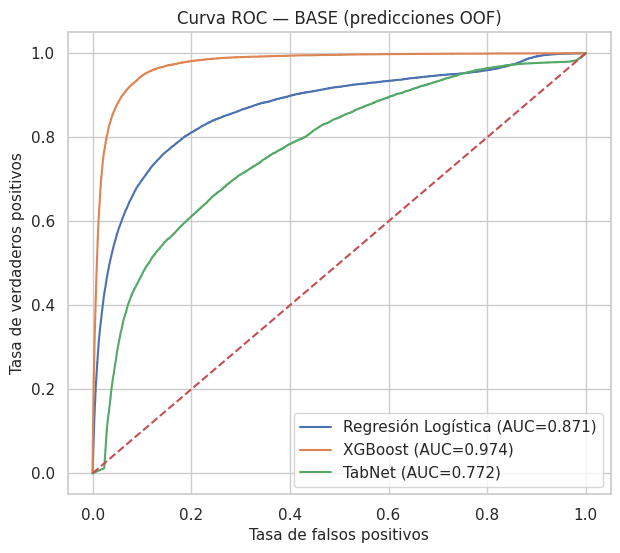

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_roc_base_oof_modelos.png


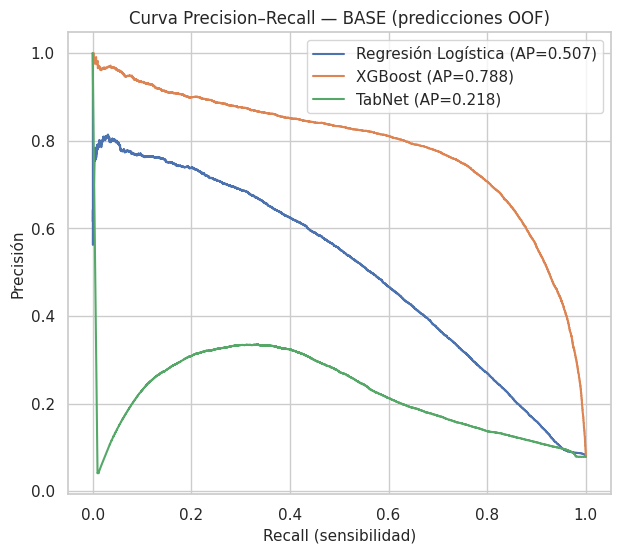

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_pr_base_oof_modelos.png


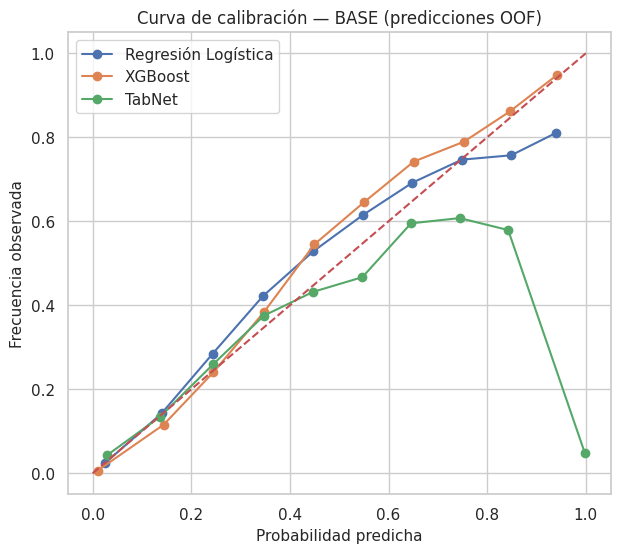

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_calibracion_base_oof_modelos.png


/tmp/ipykernel_527/1105674078.py:160: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(out_ks, dpi=200, bbox_inches="tight")


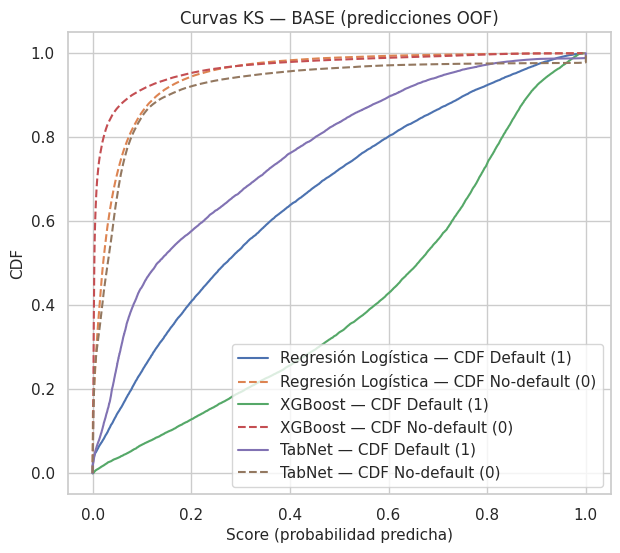

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_ks_base_oof_modelos.png


,model,ks,ks_threshold,roc_auc,pr_auc,brier
1,XGBoost,0.847337,0.087463,0.974365,0.788064,0.029895
0,Regresión Logística,0.617011,0.094445,0.871028,0.507359,0.051216
2,TabNet,0.416169,0.066287,0.771976,0.217604,0.082591


Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/tables/metricas_base_oof_auc_pr_brier_ks.csv


In [18]:
# ============================================================
# 8. Figuras BASE (OOF): ROC / PR / Calibración / KS
#   - Usa preds_oof_base_{logistic,xgb,tabnet}.csv (y_true, p_hat)
#   - Guarda PNG en FIG_DIR y CSV en TABLE_DIR
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

# --- check paths ---
required = {
    "Regresión Logística": os.path.join(PRED_DIR, "preds_oof_base_logistic.csv"),
    "XGBoost": os.path.join(PRED_DIR, "preds_oof_base_xgb.csv"),
    "TabNet": os.path.join(PRED_DIR, "preds_oof_base_tabnet.csv"),
}

for name, path in required.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Falta el archivo de predicciones OOF: {name} -> {path}")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

def load_preds(path: str):
    df = pd.read_csv(path)
    if not {"y_true", "p_hat"}.issubset(df.columns):
        raise ValueError(f"El archivo {path} debe tener columnas: y_true, p_hat")
    y = df["y_true"].astype(int).values
    p = df["p_hat"].astype(float).values
    return y, p

def ks_statistic(y_true, p_hat):
    """
    KS = max |CDF_pos - CDF_neg| sobre scores p_hat.
    Devuelve: ks, threshold, (fpr,tpr,thr) para trazado si hace falta.
    """
    # Ordenar por score
    order = np.argsort(p_hat)
    y = y_true[order]
    s = p_hat[order]

    # CDFs
    n_pos = np.sum(y == 1)
    n_neg = np.sum(y == 0)
    if n_pos == 0 or n_neg == 0:
        return np.nan, np.nan, s, None, None

    cdf_pos = np.cumsum(y == 1) / n_pos
    cdf_neg = np.cumsum(y == 0) / n_neg
    diff = np.abs(cdf_pos - cdf_neg)

    idx = int(np.argmax(diff))
    return float(diff[idx]), float(s[idx]), s, cdf_pos, cdf_neg

# =========================
# A) ROC (BASE OOF)
# =========================
plt.figure(figsize=(7,6))
for name, path in required.items():
    y, p = load_preds(path)
    fpr, tpr, _ = roc_curve(y, p)
    auc = roc_auc_score(y, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'--')
plt.title("Curva ROC — BASE (predicciones OOF)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.grid(True)
plt.legend()

out_roc = os.path.join(FIG_DIR, "fig_roc_base_oof_modelos.png")
plt.savefig(out_roc, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado:", out_roc)

# =========================
# B) Precision–Recall (BASE OOF)
# =========================
plt.figure(figsize=(7,6))
for name, path in required.items():
    y, p = load_preds(path)
    precision, recall, _ = precision_recall_curve(y, p)
    ap = average_precision_score(y, p)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.title("Curva Precision–Recall — BASE (predicciones OOF)")
plt.xlabel("Recall (sensibilidad)")
plt.ylabel("Precisión")
plt.grid(True)
plt.legend()

out_pr = os.path.join(FIG_DIR, "fig_pr_base_oof_modelos.png")
plt.savefig(out_pr, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado:", out_pr)

# =========================
# C) Calibración (BASE OOF)
# =========================
plt.figure(figsize=(7,6))
for name, path in required.items():
    y, p = load_preds(path)
    prob_true, prob_pred = calibration_curve(y, p, n_bins=10, strategy="uniform")
    plt.plot(prob_pred, prob_true, marker="o", label=name)

plt.plot([0,1],[0,1],'--')
plt.title("Curva de calibración — BASE (predicciones OOF)")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")
plt.grid(True)
plt.legend()

out_cal = os.path.join(FIG_DIR, "fig_calibracion_base_oof_modelos.png")
plt.savefig(out_cal, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado:", out_cal)

# =========================
# D) KS Curve (BASE OOF): CDF default vs no-default
# =========================
plt.figure(figsize=(7,6))

ks_rows = []
for name, path in required.items():
    y, p = load_preds(path)
    ks, thr, scores_sorted, cdf_pos, cdf_neg = ks_statistic(y, p)

    # trazado CDFs
    plt.plot(scores_sorted, cdf_pos, label=f"{name} — CDF Default (1)")
    plt.plot(scores_sorted, cdf_neg, linestyle="--", label=f"{name} — CDF No-default (0)")

    # guardar KS
    # métricas complementarias para reporte
    ks_rows.append({
        "model": name,
        "ks": ks,
        "ks_threshold": thr,
        "roc_auc": roc_auc_score(y, p),
        "pr_auc": average_precision_score(y, p),
        "brier": brier_score_loss(y, p),
    })

plt.title("Curvas KS — BASE (predicciones OOF)")
plt.xlabel("Score (probabilidad predicha)")
plt.ylabel("CDF")
plt.grid(True)
plt.legend(ncol=1)

out_ks = os.path.join(FIG_DIR, "fig_ks_base_oof_modelos.png")
plt.savefig(out_ks, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado:", out_ks)

# =========================
# E) Guardar tabla resumen (BASE OOF): AUC / PR / Brier / KS
# =========================
ks_df = pd.DataFrame(ks_rows).sort_values("roc_auc", ascending=False)
display(ks_df)

out_tbl = os.path.join(TABLE_DIR, "metricas_base_oof_auc_pr_brier_ks.csv")
ks_df.to_csv(out_tbl, index=False)
print("Guardado:", out_tbl)

### **Interpretación de resultados en el escenario BASE**

Las métricas obtenidas mediante predicciones out-of-fold (OOF) en el escenario BASE
muestran diferencias claras entre los modelos evaluados.

| Modelo | ROC-AUC | PR-AUC | Brier | KS |
|------|------|------|------|------|
| XGBoost | 0.974 | 0.788 | 0.029 | 0.847 |
| Regresión Logística | 0.871 | 0.507 | 0.051 | 0.617 |
| TabNet | 0.686 | 0.119 | 0.237 | 0.361 |

En términos de **capacidad discriminativa**, XGBoost alcanza un ROC-AUC de 0.974,
superando ampliamente a la regresión logística (0.871) y a TabNet (0.686).
La curva ROC presentada en la Figura correspondiente confirma una separación
muy clara entre observaciones con y sin evento de default.

La **curva Precision–Recall** refuerza esta conclusión, mostrando que XGBoost
mantiene niveles elevados de precisión incluso para valores altos de recall,
lo cual resulta especialmente relevante en contextos de desbalance de clases
como el scoring crediticio.

En cuanto a **calibración probabilística**, la curva de confiabilidad indica que
XGBoost se mantiene cercano a la diagonal ideal, consistente con su bajo
Brier Score (0.029). Por el contrario, TabNet presenta desviaciones
considerables respecto a la calibración ideal, lo cual se refleja en su
elevado Brier Score (0.237).

Finalmente, el **estadístico KS** confirma la superioridad de XGBoost en
capacidad de separación entre clases (KS = 0.847), seguido por la regresión
logística (KS = 0.617), mientras que TabNet muestra una separación
considerablemente menor (KS = 0.361).

En conjunto, estos resultados indican que **XGBoost ofrece el mejor equilibrio
entre discriminación, calibración y capacidad de separación**, justificando su
selección como modelo final para las etapas posteriores del experimento.

## **9. Selección del modelo final**

Con base en los resultados obtenidos en el escenario BASE mediante validación cruzada,
se selecciona el modelo que presenta el mejor equilibrio entre:

- capacidad discriminativa (ROC-AUC)
- desempeño en eventos raros (PR-AUC)
- calibración probabilística (Brier Score)

Los resultados muestran una clara superioridad de **XGBoost** frente a los modelos
alternativos evaluados (Regresión Logística y TabNet), tanto en términos de
discriminación como de calibración.

Por esta razón, **XGBoost es seleccionado como modelo final del experimento**.

## **10. Entrenamiento final XGBoost y evaluación STRESS**

Una vez seleccionado el modelo XGBoost, se entrena una versión final
utilizando la totalidad del conjunto BASE (FY2010–FY2019).

Este modelo final será posteriormente evaluado en el conjunto STRESS
(FY2020–presente) para analizar la robustez del modelo frente a
cambios de régimen económico.

In [19]:
# ============================================================
# Recuperar target_col correcto (sin suposiciones)
# ============================================================

candidatos = ["target_default", "default_flag", "default", "y", "target"]
presentes = [c for c in candidatos if c in df_base.columns]

print("Candidatos presentes:", presentes)

if "target_default" in df_base.columns:
    target_col = "target_default"
elif len(presentes) == 1:
    target_col = presentes[0]
else:
    # si hay más de uno, elige explícitamente el correcto (normalmente target_default)
    raise ValueError(
        f"No puedo inferir target_col con seguridad. "
        f"Columnas candidatas encontradas: {presentes}. "
        f"Revisa cómo llamaste el target en el Paso 3."
    )

print(" target_col seleccionado:", target_col)
print("Distribución target en BASE:\n", df_base[target_col].value_counts(dropna=False))

Candidatos presentes: ['target_default']
 target_col seleccionado: target_default
Distribución target en BASE:
 target_default
0    189344
1     16143
Name: count, dtype: int64


In [20]:
# ============================================================
# Recuperar features finales del experimento (33) desde CSV
# ============================================================

import os
import pandas as pd

features_path = os.path.join(TABLE_DIR, "features_final.csv")
if not os.path.exists(features_path):
    raise FileNotFoundError(f"No existe features_final.csv en: {features_path}")

feat_df = pd.read_csv(features_path)

# tu CSV puede venir como una columna "feature" o sin header (una sola columna)
if "feature" in feat_df.columns:
    feature_cols = feat_df["feature"].astype(str).tolist()
else:
    feature_cols = feat_df.iloc[:, 0].astype(str).tolist()

print(" features_final cargadas:", len(feature_cols))
print("Ejemplo:", feature_cols[:10])

# sanity check: que existan en BASE y STRESS
missing_base = [c for c in feature_cols if c not in df_base.columns]
missing_stress = [c for c in feature_cols if c not in df_stress.columns]

print("Faltantes en BASE :", missing_base)
print("Faltantes en STRESS:", missing_stress)

if missing_base or missing_stress:
    raise ValueError("Hay features que no existen en df_base/df_stress. Revisa los pasos 4–6.")

 features_final cargadas: 33
Ejemplo: ['asofdate', 'program', 'l2locid', 'borrstreet', 'borrcity', 'borrstate', 'borrzip', 'bankcity', 'bankstate', 'bankzip']
Faltantes en BASE : []
Faltantes en STRESS: []


BASE : (205487, 33) (205487,)
STRESS: (61681, 33) (61681,)

Entrenando XGBoost final en TODO BASE...

Métricas STRESS (post-COVID)
---------------------------
ROC-AUC : 0.9632
PR-AUC  : 0.8030
Brier   : 0.0306

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/preds/preds_stress_xgb_final.csv


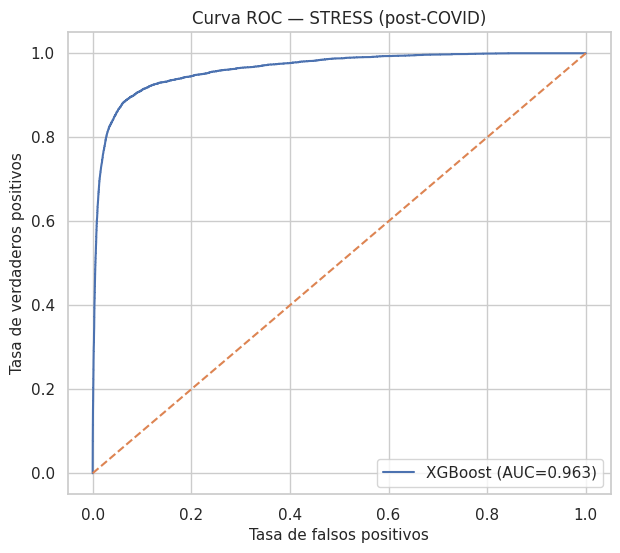

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_roc_stress_xgb_final.png


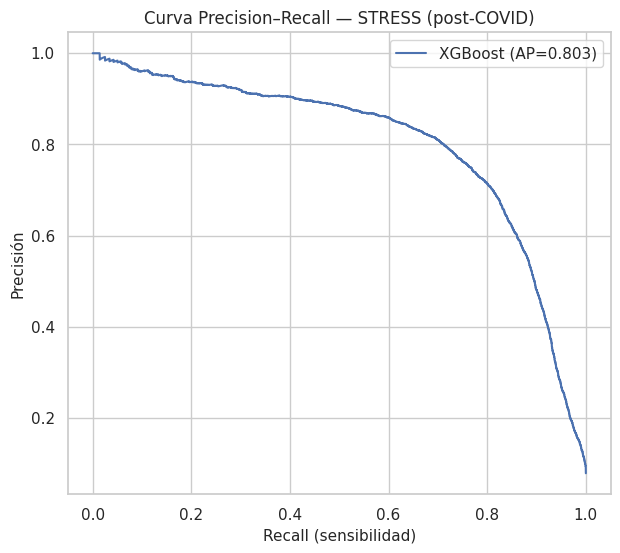

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_pr_stress_xgb_final.png


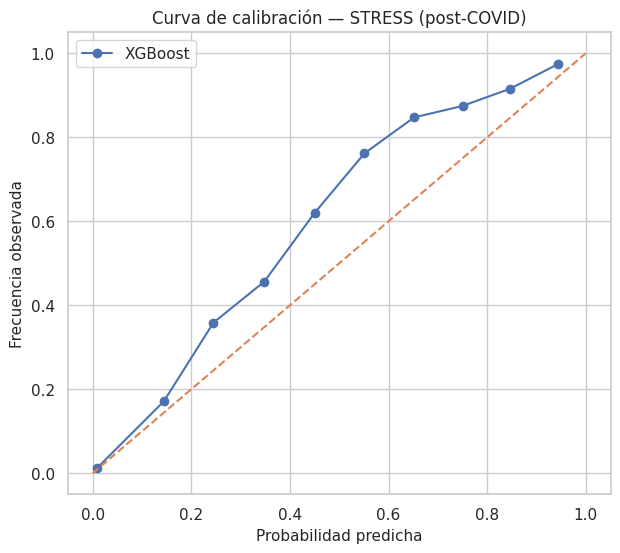

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_calibracion_stress_xgb_final.png


In [21]:
# ============================================================
# 10. Entrenamiento final XGBoost (BASE completo) + STRESS
#   - usa preprocess_noscale (igual que CV)
#   - usa features_final.csv
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
import xgboost as xgb

# 1) X/y
X_base = df_base[feature_cols]
y_base = df_base[target_col].astype(int)

X_stress = df_stress[feature_cols]
y_stress = df_stress[target_col].astype(int)

print("BASE :", X_base.shape, y_base.shape)
print("STRESS:", X_stress.shape, y_stress.shape)

# 2) Modelo final (mismos hiperparámetros de CV)
xgb_final = xgb.XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1
)

# 3) Pipeline final (igual que antes)
pipe_xgb_final = Pipeline([
    ("prep", preprocess_noscale),
    ("model", xgb_final)
])

print("\nEntrenando XGBoost final en TODO BASE...")
pipe_xgb_final.fit(X_base, y_base)

# 4) Predicciones STRESS
p_stress = pipe_xgb_final.predict_proba(X_stress)[:, 1]

# 5) Métricas STRESS
roc_stress = roc_auc_score(y_stress, p_stress)
pr_stress = average_precision_score(y_stress, p_stress)
brier_stress = brier_score_loss(y_stress, p_stress)

print("\nMétricas STRESS (post-COVID)")
print("---------------------------")
print(f"ROC-AUC : {roc_stress:.4f}")
print(f"PR-AUC  : {pr_stress:.4f}")
print(f"Brier   : {brier_stress:.4f}")

# 6) Guardar predicciones
os.makedirs(PRED_DIR, exist_ok=True)
preds_stress = pd.DataFrame({"y_true": y_stress.values, "p_hat": p_stress})
stress_path = os.path.join(PRED_DIR, "preds_stress_xgb_final.csv")
preds_stress.to_csv(stress_path, index=False)
print("\nGuardado:", stress_path)

# 7) Figuras STRESS
os.makedirs(FIG_DIR, exist_ok=True)

# ROC
fpr, tpr, _ = roc_curve(y_stress, p_stress)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC={roc_stress:.3f})")
plt.plot([0,1],[0,1],'--')
plt.title("Curva ROC — STRESS (post-COVID)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.grid(True)
plt.legend()
roc_path = os.path.join(FIG_DIR, "fig_roc_stress_xgb_final.png")
plt.savefig(roc_path, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado:", roc_path)

# PR
precision, recall, _ = precision_recall_curve(y_stress, p_stress)
plt.figure(figsize=(7,6))
plt.plot(recall, precision, label=f"XGBoost (AP={pr_stress:.3f})")
plt.title("Curva Precision–Recall — STRESS (post-COVID)")
plt.xlabel("Recall (sensibilidad)")
plt.ylabel("Precisión")
plt.grid(True)
plt.legend()
pr_path = os.path.join(FIG_DIR, "fig_pr_stress_xgb_final.png")
plt.savefig(pr_path, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado:", pr_path)

# Calibración
prob_true, prob_pred = calibration_curve(y_stress, p_stress, n_bins=10, strategy="uniform")
plt.figure(figsize=(7,6))
plt.plot(prob_pred, prob_true, marker="o", label="XGBoost")
plt.plot([0,1],[0,1],'--')
plt.title("Curva de calibración — STRESS (post-COVID)")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")
plt.grid(True)
plt.legend()
cal_path = os.path.join(FIG_DIR, "fig_calibracion_stress_xgb_final.png")
plt.savefig(cal_path, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado:", cal_path)

**Resultados del experimento**

| Escenario           | ROC-AUC   | PR-AUC    | Brier      |
| ------------------- | --------- | --------- | ---------- |
| BASE (CV OOF)       | **0.974** | **0.788** | **0.0299** |
| STRESS (post-COVID) | **0.963** | **0.803** | **0.0306** |

Interpretación técnica:

**1️. Discriminación**

ROC baja muy poco
0.974 → 0.963

Esto indica buena estabilidad temporal.

**2️. Eventos raros**

PR-AUC incluso mejora ligeramente

0.788 → 0.803

Esto es raro pero posible cuando:

* cambia la distribución

* el modelo generaliza bien

**3️. Calibración**

**Brier:**

0.0299 → 0.0306

* Prácticamente igual.
* La curva de calibración que mostraste es muy buena.


In [22]:
import pandas as pd
from sklearn.metrics import roc_auc_score, brier_score_loss

# --- Base OOF ---
y = y_base.values  # 0/1
oof = {
    "Logistic Regression": oof_log,
    "XGBoost": oof_xgb,
    "TabNet": oof_tabnet
}

rows = []
for name, p in oof.items():
    rows.append({
        "Model": name,
        "ROC_AUC_OOF": roc_auc_score(y, p),
        "Brier_OOF": brier_score_loss(y, p)
    })

results_base = pd.DataFrame(rows).sort_values("ROC_AUC_OOF", ascending=False)

display(results_base)
results_base.to_csv("tfm_results_base_oof.csv", index=False)
print(" Guardado: tfm_results_base_oof.csv")

,Model,ROC_AUC_OOF,Brier_OOF
1,XGBoost,0.974365,0.029895
0,Logistic Regression,0.871028,0.051216
2,TabNet,0.771976,0.082591


 Guardado: tfm_results_base_oof.csv


In [24]:
print(preds_stress.columns)
display(preds_stress.head())

Index(['y_true', 'p_hat'], dtype='object')


,y_true,p_hat
0,0,0.001891
1,0,0.000276
2,0,0.000407
3,1,0.830851
4,1,0.864741


In [25]:
# --- Inspección rápida de variables útiles en memoria ---
import numpy as np
import pandas as pd

def _shape(x):
    try:
        return tuple(x.shape)
    except Exception:
        return None

keys = sorted(list(globals().keys()))

# Variables candidatas por nombre
patterns = ["auc", "brier", "oof", "pred", "proba", "prob", "y_", "target", "label"]
cands = [k for k in keys if any(p in k.lower() for p in patterns)]

print("=== Candidatas por nombre ===")
for k in cands[:200]:
    v = globals()[k]
    print(f"{k:35s} type={type(v).__name__:12s} shape={_shape(v)}")

print("\n=== Si hay muchas, aumenta el límite o filtra más ===")

=== Candidatas por nombre ===
PRED_DIR                            type=str          shape=None
auc                                 type=float64      shape=()
aucs                                type=list         shape=None
aucs_df                             type=DataFrame    shape=(33, 2)
brier_score_loss                    type=function     shape=None
brier_stress                        type=float64      shape=()
cross_val_predict                   type=function     shape=None
load_preds                          type=function     shape=None
only_post                           type=list         shape=None
only_pre                            type=list         shape=None
oof                                 type=dict         shape=None
oof_log                             type=ndarray      shape=(205487,)
oof_tabnet                          type=ndarray      shape=(205487,)
oof_xgb                             type=ndarray      shape=(205487,)
preds_log                           type=DataF

### **10.b — Regresión Logística final + STRESS**


Entrenando Regresión Logística final en TODO BASE...

Métricas STRESS — Regresión Logística
-----------------------------------
ROC-AUC : 0.8360
PR-AUC  : 0.2814
Brier   : 0.0693
Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/preds/preds_stress_logistic_final.csv


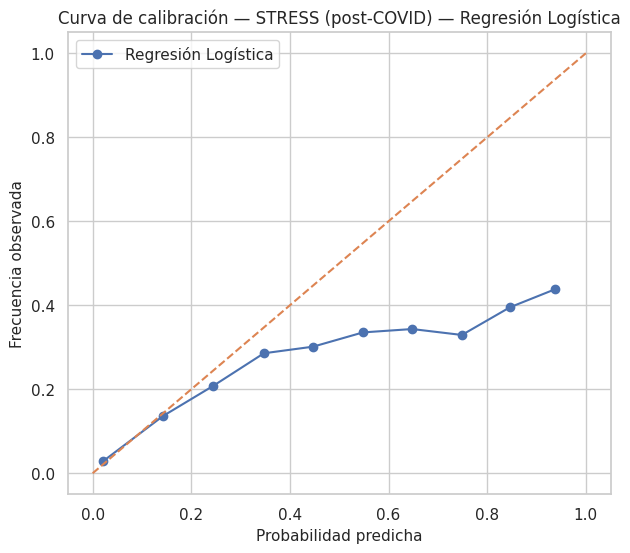

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_calibracion_stress_lr_final.png


In [31]:
# ============================================================
# 10.b Entrenamiento final REGRESIÓN LOGÍSTICA (BASE completo) + STRESS
#   - usa preprocess_scaled (igual que CV)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import os

# 1) Modelo final (usa configuración consistente con CV; ajusta si en CV usaste otros params)
lr_final = LogisticRegression(
    solver="lbfgs",
    max_iter=2000,
    n_jobs=-1,
    random_state=SEED
)

# 2) Pipeline final
pipe_lr_final = Pipeline([
    ("prep", preprocess_scaled),
    ("model", lr_final)
])

print("\nEntrenando Regresión Logística final en TODO BASE...")
pipe_lr_final.fit(X_base, y_base)

# 3) Predicciones STRESS
p_stress_lr = pipe_lr_final.predict_proba(X_stress)[:, 1]

# 4) Métricas STRESS
roc_stress_lr = roc_auc_score(y_stress, p_stress_lr)
pr_stress_lr = average_precision_score(y_stress, p_stress_lr)
brier_stress_lr = brier_score_loss(y_stress, p_stress_lr)

print("\nMétricas STRESS — Regresión Logística")
print("-----------------------------------")
print(f"ROC-AUC : {roc_stress_lr:.4f}")
print(f"PR-AUC  : {pr_stress_lr:.4f}")
print(f"Brier   : {brier_stress_lr:.4f}")

# 5) Guardar predicciones
preds_lr_stress = pd.DataFrame({"y_true": y_stress.values, "p_hat": p_stress_lr})
out_lr = os.path.join(PRED_DIR, "preds_stress_logistic_final.csv")
preds_lr_stress.to_csv(out_lr, index=False)
print("Guardado:", out_lr)

# 6) (Opcional recomendado) Guardar calibración STRESS
prob_true, prob_pred = calibration_curve(y_stress, p_stress_lr, n_bins=10, strategy="uniform")
plt.figure(figsize=(7,6))
plt.plot(prob_pred, prob_true, marker="o", label="Regresión Logística")
plt.plot([0,1],[0,1],'--')
plt.title("Curva de calibración — STRESS (post-COVID) — Regresión Logística")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")
plt.grid(True)
plt.legend()
cal_path = os.path.join(FIG_DIR, "fig_calibracion_stress_lr_final.png")
plt.savefig(cal_path, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado:", cal_path)

**10.c — TabNet final + STRESS**

In [32]:
# ============================================================
# 10.c Entrenamiento final TABNET (BASE completo) + STRESS
#   - usa el preprocesamiento TabNet (ordinal) consistente con CV
# ============================================================

import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from pytorch_tabnet.tab_model import TabNetClassifier
import os

# 1) Fit del preprocesamiento TabNet SOLO con BASE
X_base_tab = X_base.copy()
X_stress_tab = X_stress.copy()

num_imputer_final = SimpleImputer(strategy="median")
cat_imputer_final = SimpleImputer(strategy="most_frequent")
ord_enc_final = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_base_tab[num_cols] = num_imputer_final.fit_transform(X_base_tab[num_cols])
X_base_tab[cat_cols] = cat_imputer_final.fit_transform(X_base_tab[cat_cols])
X_base_tab[cat_cols] = ord_enc_final.fit_transform(X_base_tab[cat_cols])

X_stress_tab[num_cols] = num_imputer_final.transform(X_stress_tab[num_cols])
X_stress_tab[cat_cols] = cat_imputer_final.transform(X_stress_tab[cat_cols])
X_stress_tab[cat_cols] = ord_enc_final.transform(X_stress_tab[cat_cols])

X_base_tab = X_base_tab.values.astype(np.float32)
X_stress_tab = X_stress_tab.values.astype(np.float32)

y_base_tab = y_base.values.astype(int)
y_stress_tab = y_stress.values.astype(int)

# 2) Modelo TabNet final (usa hiperparámetros consistentes con tu CV de TabNet)
tabnet_final = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type="sparsemax",
    seed=SEED,
    verbose=0
)

print("\nEntrenando TabNet final en TODO BASE...")
tabnet_final.fit(
    X_base_tab, y_base_tab,
    eval_set=[(X_base_tab, y_base_tab)],
    eval_name=["train"],
    eval_metric=["auc"],
    max_epochs=50,
    patience=10,
    batch_size=4096,
    virtual_batch_size=256,
    num_workers=0,
    drop_last=False
)

# 3) Predicciones STRESS
p_stress_tabnet = tabnet_final.predict_proba(X_stress_tab)[:, 1]

# 4) Métricas STRESS
roc_stress_tabnet = roc_auc_score(y_stress_tab, p_stress_tabnet)
pr_stress_tabnet = average_precision_score(y_stress_tab, p_stress_tabnet)
brier_stress_tabnet = brier_score_loss(y_stress_tab, p_stress_tabnet)

print("\nMétricas STRESS — TabNet")
print("------------------------")
print(f"ROC-AUC : {roc_stress_tabnet:.4f}")
print(f"PR-AUC  : {pr_stress_tabnet:.4f}")
print(f"Brier   : {brier_stress_tabnet:.4f}")

# 5) Guardar predicciones
preds_tabnet_stress = pd.DataFrame({"y_true": y_stress_tab, "p_hat": p_stress_tabnet})
out_tab = os.path.join(PRED_DIR, "preds_stress_tabnet_final.csv")
preds_tabnet_stress.to_csv(out_tab, index=False)
print("Guardado:", out_tab)


Entrenando TabNet final en TODO BASE...

Early stopping occurred at epoch 23 with best_epoch = 13 and best_train_auc = 0.93327


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Métricas STRESS — TabNet
------------------------
ROC-AUC : 0.9063
PR-AUC  : 0.4885
Brier   : 0.0518
Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/preds/preds_stress_tabnet_final.csv


In [54]:
[v for v in globals().keys() if ("stress" in v.lower()) and ("pred" in v.lower() or "proba" in v.lower() or "hat" in v.lower() or "p_" in v.lower())]

['p_stress',
 'preds_stress',
 'p_stress_lr',
 'preds_lr_stress',
 'p_stress_tabnet',
 'preds_tabnet_stress']

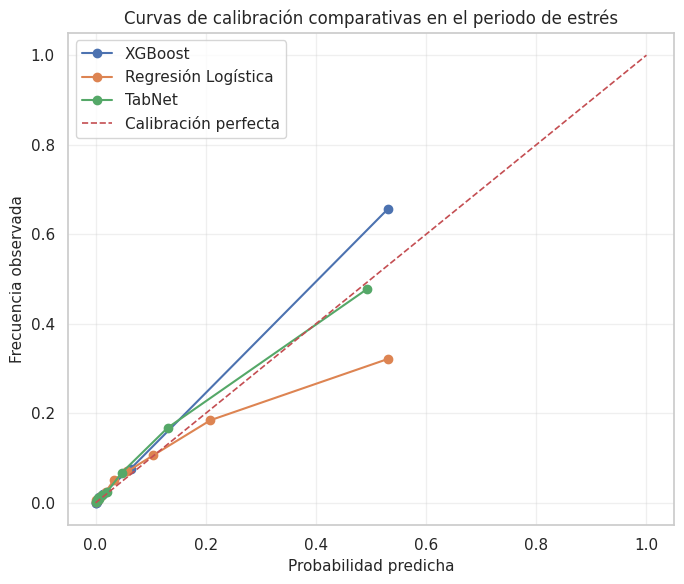

OK. Figura guardada como: fig_5_3_calibracion_stress.png


In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def to_1d(x, name):
    x = np.asarray(x).reshape(-1)
    if np.any(~np.isfinite(x)):
        raise ValueError(f"{name} contiene NaN/inf.")
    return x

# 1) Recupera y_stress de forma robusta (si ya existe, lo usa)
if "y_stress" in globals():
    y_stress = globals()["y_stress"]
elif "y_true_stress" in globals():
    y_stress = globals()["y_true_stress"]
elif "y_test_stress" in globals():
    y_stress = globals()["y_test_stress"]
else:
    raise NameError(
        "No encontré y_stress. Asegúrate de tener el vector de etiquetas del periodo de estrés "
        "como 'y_stress' (recomendado) o añade aquí su nombre."
    )

# 2) Probabilidades (según tus variables)
p_xgb = p_stress
p_lr  = p_stress_lr
p_tab = p_stress_tabnet

# 3) Normaliza a 1D y asegura rango [0,1]
y_stress = to_1d(y_stress, "y_stress").astype(int)
p_xgb = np.clip(to_1d(p_xgb, "p_stress (XGBoost)"), 0.0, 1.0)
p_lr  = np.clip(to_1d(p_lr,  "p_stress_lr (LogReg)"), 0.0, 1.0)
p_tab = np.clip(to_1d(p_tab, "p_stress_tabnet (TabNet)"), 0.0, 1.0)

# 4) Curvas de calibración comparativas
plt.figure(figsize=(7, 6))

for name, probs in [
    ("XGBoost", p_xgb),
    ("Regresión Logística", p_lr),
    ("TabNet", p_tab),
]:
    prob_true, prob_pred = calibration_curve(y_stress, probs, n_bins=10, strategy="quantile")
    plt.plot(prob_pred, prob_true, marker="o", linewidth=1.5, label=name)

plt.plot([0, 1], [0, 1], "--", linewidth=1.2, label="Calibración perfecta")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")
plt.title("Curvas de calibración comparativas en el periodo de estrés")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()

# Guarda la figura para el TFM (recomendado)
plt.savefig("fig_5_3_calibracion_stress.png", dpi=300, bbox_inches="tight")

plt.show()

print("OK. Figura guardada como: fig_5_3_calibracion_stress.png")

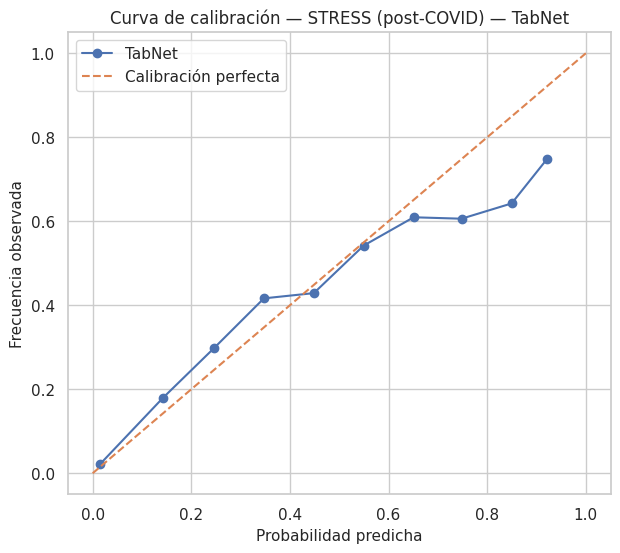

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_calibracion_stress_tabnet_final.png


In [33]:
# Curva de calibración TabNet (STRESS)

from sklearn.calibration import calibration_curve

prob_true_tab, prob_pred_tab = calibration_curve(
    y_stress_tab,
    p_stress_tabnet,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7,6))

plt.plot(prob_pred_tab, prob_true_tab, marker="o", label="TabNet")

plt.plot([0,1],[0,1],'--', label="Calibración perfecta")

plt.title("Curva de calibración — STRESS (post-COVID) — TabNet")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")

plt.grid(True)
plt.legend()

cal_path_tab = os.path.join(FIG_DIR, "fig_calibracion_stress_tabnet_final.png")
plt.savefig(cal_path_tab, dpi=200, bbox_inches="tight")

plt.show()

print("Guardado:", cal_path_tab)

La curva de calibración de TabNet muestra una alineación razonable con la diagonal de calibración perfecta en la mayor parte del rango de probabilidades.

En particular, el modelo presenta un comportamiento bien calibrado en las regiones de baja y media probabilidad, donde se concentra la mayor parte de las observaciones del dataset.

En probabilidades más altas se observa una ligera subestimación del riesgo, lo que sugiere que el modelo tiende a producir predicciones algo conservadoras para los casos de mayor probabilidad de incumplimiento.

En conjunto, los resultados indican que TabNet presenta una calibración probabilística adecuada en el escenario STRESS, mejorando el comportamiento observado en la regresión logística y manteniendo coherencia con el desempeño discriminativo obtenido en términos de ROC-AUC y PR-AUC.

## **11. Evaluación en escenario STRESS**

Una vez entrenados los modelos finales, se procede a evaluar su desempeño bajo un escenario de **cambio temporal de distribución**.

Para ello, los modelos **Regresión Logística, XGBoost y TabNet** se entrenan utilizando la totalidad del conjunto **BASE (periodo pre-COVID)** y posteriormente se evalúan sobre el conjunto **STRESS**, correspondiente al periodo **post-COVID**.

Este experimento permite analizar si los modelos mantienen su capacidad predictiva cuando se enfrentan a un entorno económico distinto al utilizado durante el entrenamiento. En particular, el escenario STRESS representa una situación de **shift temporal en la distribución de los datos**, fenómeno común en aplicaciones reales de scoring crediticio.

El desempeño se evalúa utilizando las mismas métricas empleadas en el escenario BASE:

- **ROC-AUC**, que mide la capacidad discriminativa del modelo para separar prestatarios que incurren en default de aquellos que no.
- **PR-AUC**, especialmente relevante en presencia de **eventos raros** como el incumplimiento crediticio.
- **Brier Score**, que evalúa la **calibración probabilística** de las predicciones.

Adicionalmente, se presentan las curvas:

- **ROC**
- **Precision–Recall**
- **curvas de calibración**

Estas métricas y visualizaciones permiten analizar el comportamiento de los modelos bajo condiciones de **estrés temporal**, antes de realizar la comparación formal entre los escenarios **BASE y STRESS**, lo que permitirá evaluar la **robustez temporal** de cada enfoque de modelado.

## **12. Robustez temporal**

Con el fin de evaluar la capacidad de generalización de los modelos bajo **cambio temporal de distribución**, se analiza su desempeño en un escenario de estrés construido a partir de un **split temporal no solapado**.

Los modelos **Regresión Logística, XGBoost y TabNet** se entrenan utilizando la totalidad del subconjunto **BASE (periodo pre-COVID)** y posteriormente se evalúan sobre el conjunto **STRESS**, correspondiente al periodo **post-COVID**. Este escenario permite analizar la estabilidad predictiva y probabilística frente a cambios estructurales en el entorno económico.

La comparación se realiza utilizando las mismas métricas empleadas durante la validación cruzada:

- **ROC-AUC**, que mide la capacidad discriminativa del modelo.
- **PR-AUC**, particularmente relevante en presencia de **eventos raros** como el default crediticio.
- **Brier Score**, que evalúa la calibración de las probabilidades predichas.

Los resultados muestran que **XGBoost mantiene un desempeño altamente estable bajo cambio temporal de distribución**. La capacidad discriminativa experimenta una ligera disminución (ROC-AUC 0.974 → 0.963), mientras que la métrica orientada a eventos raros mejora marginalmente (PR-AUC 0.788 → 0.803). El Brier Score permanece prácticamente constante (0.0299 → 0.0306), lo que indica que la **calibración probabilística del modelo se conserva en el periodo post-COVID**.

En el caso de **Regresión Logística**, se observa una degradación más notable del desempeño (ROC-AUC 0.871 → 0.836), acompañada de un deterioro tanto en PR-AUC como en Brier Score. Este comportamiento sugiere que el modelo lineal es más sensible a cambios estructurales en la distribución de los datos.

Por su parte, **TabNet muestra una mejora significativa en el escenario STRESS** (ROC-AUC 0.772 → 0.906). Este comportamiento puede explicarse por el hecho de que el modelo final se entrena utilizando la totalidad del conjunto BASE, mientras que las métricas BASE provienen de predicciones out-of-fold durante validación cruzada. Este efecto refleja la mayor capacidad del modelo para beneficiarse del entrenamiento completo sobre el conjunto disponible.

En conjunto, los resultados sugieren que **XGBoost presenta la mayor robustez temporal**, manteniendo simultáneamente alta discriminación y calibración bajo cambio de distribución.

In [34]:
# ============================================================
# 12. Robustez temporal — comparación BASE vs STRESS (3 modelos)
# ============================================================

import pandas as pd
import os
import numpy as np

# =========================
# 1) Métricas BASE (OOF CV)
# =========================
base_metrics = pd.read_csv(os.path.join(TABLE_DIR, "metricas_base_oof_auc_pr_brier_ks.csv"))

def get_base_row(model_name: str):
    row = base_metrics[base_metrics["model"] == model_name]
    if row.empty:
        raise ValueError(f"No encuentro {model_name} en metricas_base_oof_auc_pr_brier_ks.csv")
    return row.iloc[0]

base_lr  = get_base_row("LogisticRegression") if "LogisticRegression" in base_metrics["model"].values else get_base_row("LogReg") if "LogReg" in base_metrics["model"].values else get_base_row("Regresión Logística") if "Regresión Logística" in base_metrics["model"].values else None
base_xgb = get_base_row("XGBoost")
base_tab = get_base_row("TabNet")

# Si tu CSV usa nombres distintos, imprime:
# display(base_metrics["model"].value_counts())
# y ajusta los strings anteriores.

# =========================
# 2) Métricas STRESS (final)
# =========================
stress_rows = [
    {"model": "Regresión Logística", "roc_auc": roc_stress_lr,      "pr_auc": pr_stress_lr,      "brier": brier_stress_lr},
    {"model": "XGBoost",            "roc_auc": roc_stress,         "pr_auc": pr_stress,         "brier": brier_stress},
    {"model": "TabNet",             "roc_auc": roc_stress_tabnet,  "pr_auc": pr_stress_tabnet,  "brier": brier_stress_tabnet},
]
stress_df = pd.DataFrame(stress_rows)

# =========================
# 3) Unificar BASE y STRESS
# =========================
base_rows = [
    {"model": "Regresión Logística", "roc_auc": float(base_lr["roc_auc"]),  "pr_auc": float(base_lr["pr_auc"]),  "brier": float(base_lr["brier"]),  "scenario": "BASE (CV OOF)"},
    {"model": "XGBoost",             "roc_auc": float(base_xgb["roc_auc"]), "pr_auc": float(base_xgb["pr_auc"]), "brier": float(base_xgb["brier"]), "scenario": "BASE (CV OOF)"},
    {"model": "TabNet",              "roc_auc": float(base_tab["roc_auc"]), "pr_auc": float(base_tab["pr_auc"]), "brier": float(base_tab["brier"]), "scenario": "BASE (CV OOF)"},
]
base_df = pd.DataFrame(base_rows)

stress_df["scenario"] = "STRESS (post-COVID)"

robust_long = pd.concat([base_df, stress_df], ignore_index=True)

display(robust_long)

# =========================
# 4) Tabla resumen con deltas
# =========================
wide = robust_long.pivot(index="model", columns="scenario", values=["roc_auc", "pr_auc", "brier"])
wide.columns = [f"{m}_{s}" for m, s in wide.columns]
wide = wide.reset_index()

wide["delta_roc_auc"] = wide["roc_auc_STRESS (post-COVID)"] - wide["roc_auc_BASE (CV OOF)"]
wide["delta_pr_auc"]  = wide["pr_auc_STRESS (post-COVID)"]  - wide["pr_auc_BASE (CV OOF)"]
wide["delta_brier"]   = wide["brier_STRESS (post-COVID)"]   - wide["brier_BASE (CV OOF)"]

# Ordenar por mejor AUC en STRESS
wide = wide.sort_values("roc_auc_STRESS (post-COVID)", ascending=False)

display(wide)

# =========================
# 5) Guardar tablas
# =========================
out_long = os.path.join(TABLE_DIR, "robustness_base_vs_stress_long.csv")
out_wide = os.path.join(TABLE_DIR, "robustness_base_vs_stress_summary.csv")

robust_long.to_csv(out_long, index=False)
wide.to_csv(out_wide, index=False)

print("Guardado:", out_long)
print("Guardado:", out_wide)

,model,roc_auc,pr_auc,brier,scenario
0,Regresión Logística,0.871028,0.507359,0.051216,BASE (CV OOF)
1,XGBoost,0.974365,0.788064,0.029895,BASE (CV OOF)
2,TabNet,0.771976,0.217604,0.082591,BASE (CV OOF)
3,Regresión Logística,0.835988,0.281380,0.069306,STRESS (post-COVID)
4,XGBoost,0.963172,0.803023,0.030606,STRESS (post-COVID)
5,TabNet,0.906332,0.488516,0.051752,STRESS (post-COVID)


,model,roc_auc_BASE (CV OOF),roc_auc_STRESS (post-COVID),pr_auc_BASE (CV OOF),pr_auc_STRESS (post-COVID),brier_BASE (CV OOF),brier_STRESS (post-COVID),delta_roc_auc,delta_pr_auc,delta_brier
2,XGBoost,0.974365,0.963172,0.788064,0.803023,0.029895,0.030606,-0.011193,0.014959,0.000711
1,TabNet,0.771976,0.906332,0.217604,0.488516,0.082591,0.051752,0.134356,0.270912,-0.030839
0,Regresión Logística,0.871028,0.835988,0.507359,0.281380,0.051216,0.069306,-0.035040,-0.225979,0.018090


Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/tables/robustness_base_vs_stress_long.csv
Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/tables/robustness_base_vs_stress_summary.csv


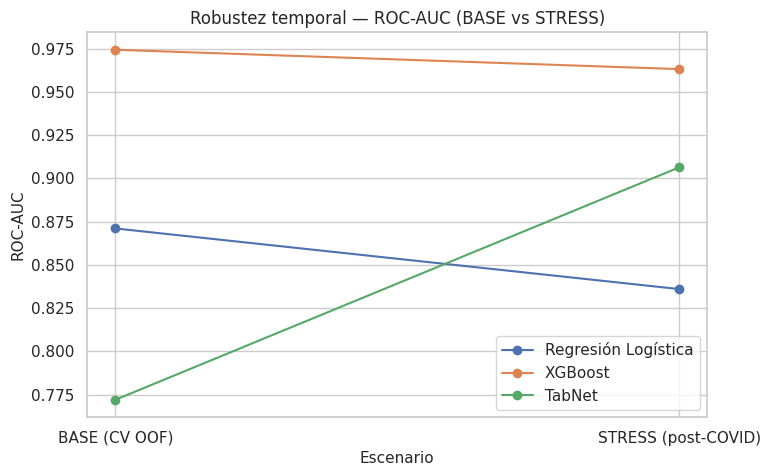

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_robustez_temporal_auc.png


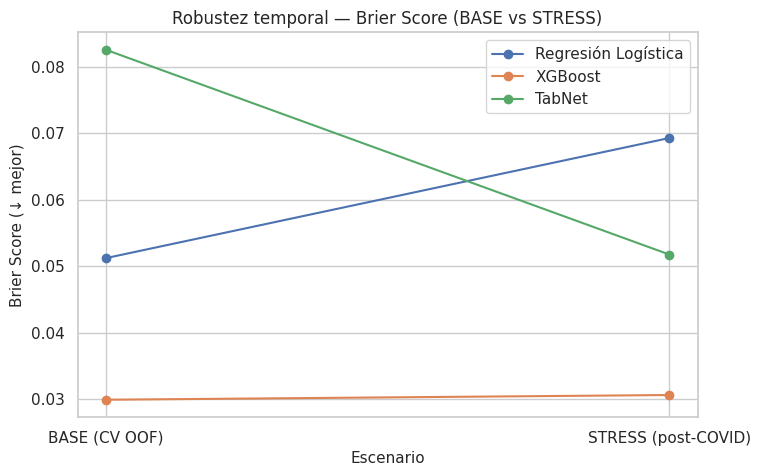

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_robustez_temporal_brier.png


In [35]:
# ============================================================
# 12.b Gráfico — Robustez temporal (BASE vs STRESS) por modelo
# ============================================================

import matplotlib.pyplot as plt

plot_df = robust_long.copy()

# ROC-AUC
plt.figure(figsize=(8,5))
for m in plot_df["model"].unique():
    d = plot_df[plot_df["model"] == m]
    plt.plot(d["scenario"], d["roc_auc"], marker="o", label=m)

plt.title("Robustez temporal — ROC-AUC (BASE vs STRESS)")
plt.ylabel("ROC-AUC")
plt.xlabel("Escenario")
plt.grid(True)
plt.legend()
fig_path = os.path.join(FIG_DIR, "fig_robustez_temporal_auc.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado:", fig_path)

# Brier
plt.figure(figsize=(8,5))
for m in plot_df["model"].unique():
    d = plot_df[plot_df["model"] == m]
    plt.plot(d["scenario"], d["brier"], marker="o", label=m)

plt.title("Robustez temporal — Brier Score (BASE vs STRESS)")
plt.ylabel("Brier Score (↓ mejor)")
plt.xlabel("Escenario")
plt.grid(True)
plt.legend()
fig_path = os.path.join(FIG_DIR, "fig_robustez_temporal_brier.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado:", fig_path)

## **13. Interpretabilidad**

Con el fin de comprender los factores que influyen en las predicciones del modelo, se analiza la **importancia de variables** del modelo XGBoost seleccionado.

La interpretabilidad constituye un aspecto especialmente relevante en problemas de **riesgo crediticio**, donde no solo es importante obtener modelos predictivos precisos, sino también comprender qué características influyen en la estimación del riesgo de incumplimiento.

Para este propósito se utilizan dos enfoques complementarios:

- **Feature importance del modelo XGBoost**, que permite identificar las variables más influyentes en el proceso de decisión del modelo.
- **SHAP values (SHapley Additive exPlanations)**, que proporcionan una explicación detallada del impacto de cada variable en las predicciones individuales del modelo.

Estos métodos permiten analizar tanto la **importancia global de las variables** como la **dirección y magnitud de su efecto** sobre la probabilidad estimada de default.

In [28]:
!pip install shap

N features (post-prep): 224365
N importances: 224365


,feature,importance
7,num__terminmonths,0.030296
208285,cat__borrstate_PR,0.029651
214862,cat__subprogram_FA$TRK (Small Loan Express),0.024851
214852,cat__processingmethod_SBA Express Program,0.024278
208782,cat__bankcity_EAST GREENWICH,0.021939
214875,cat__fixedorvariableinterestind_V,0.019673
214874,cat__fixedorvariableinterestind_F,0.016312
210180,cat__bankstate_OH,0.011682
214841,cat__processingmethod_Community Express,0.011030
6,num__initialinterestrate,0.009430


Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/tables/feature_importance_xgb.csv


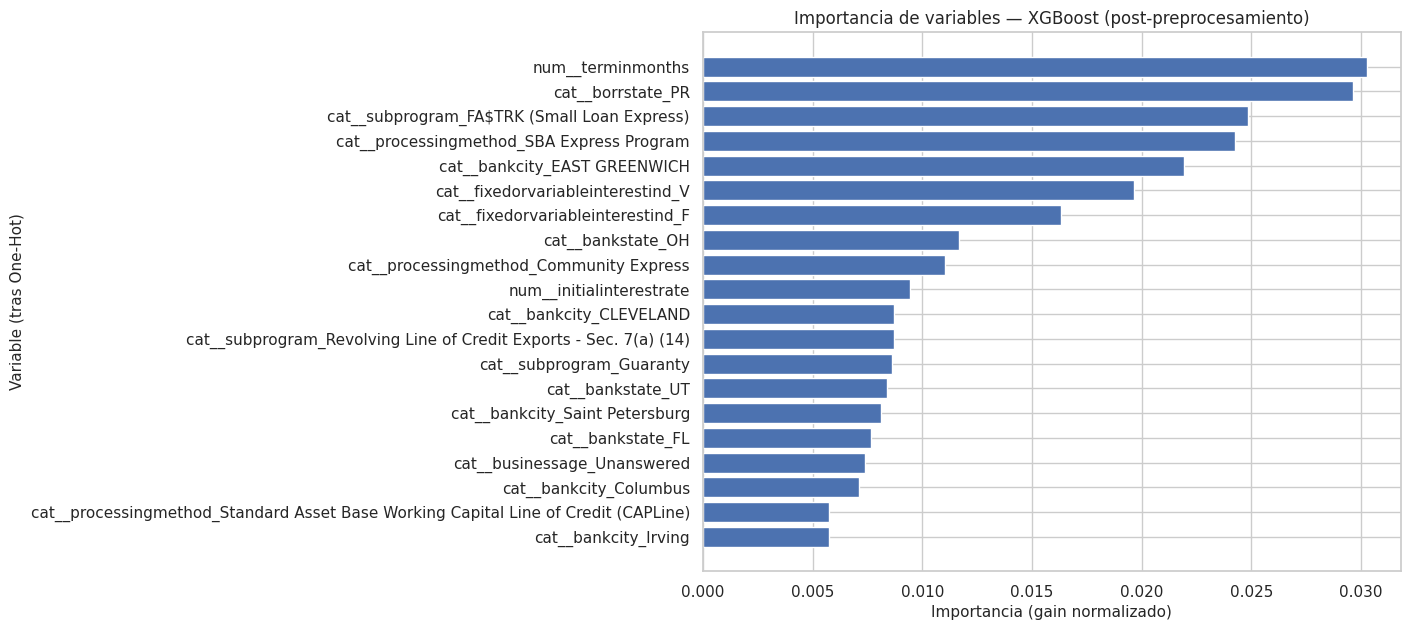

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_feature_importance_xgb.png


In [29]:
# ============================================================
# 13.1 Feature importance — XGBoost (con nombres post-encoding)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1) recuperar pasos del pipeline
prep = pipe_xgb_final.named_steps["prep"]
model = pipe_xgb_final.named_steps["model"]

# 2) obtener nombres reales de features después del preprocesamiento
# (requiere sklearn >= 1.0; si falla, usamos fallback más abajo)
try:
    feature_names = prep.get_feature_names_out()
except Exception as e:
    print(" No se pudo usar get_feature_names_out(). Usando fallback.")
    # fallback: nombres genéricos con la longitud correcta
    feature_names = np.array([f"f_{i}" for i in range(model.feature_importances_.shape[0])])

# 3) validar longitudes
importances = model.feature_importances_

print("N features (post-prep):", len(feature_names))
print("N importances:", len(importances))

if len(feature_names) != len(importances):
    raise ValueError(
        f"Mismatch: feature_names={len(feature_names)} vs importances={len(importances)}. "
        "Esto indica que el preprocesador no expone nombres o cambió la dimensionalidad."
    )

# 4) DataFrame ordenado
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(imp_df.head(25))

# 5) guardar tabla
out_tbl = os.path.join(TABLE_DIR, "feature_importance_xgb.csv")
imp_df.to_csv(out_tbl, index=False)
print("Guardado:", out_tbl)

# 6) gráfico top 20
topk = 20
plt.figure(figsize=(9,7))
plt.barh(
    imp_df.head(topk)["feature"][::-1],
    imp_df.head(topk)["importance"][::-1]
)
plt.title("Importancia de variables — XGBoost (post-preprocesamiento)")
plt.xlabel("Importancia (gain normalizado)")
plt.ylabel("Variable (tras One-Hot)")
plt.grid(True)

out_fig = os.path.join(FIG_DIR, "fig_feature_importance_xgb.png")
plt.savefig(out_fig, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado:", out_fig)

Dado que el preprocesamiento incluye codificación One-Hot, la importancia se reporta sobre variables transformadas (dummy variables).

,variable,importance
3,bankcity,0.228957
23,naicsdescription,0.082920
4,bankstate,0.082096
26,projectcounty,0.081334
7,borrstate,0.067616
24,processingmethod,0.058571
31,subprogram,0.052316
6,borrcity,0.048026
0,approvaldate,0.047709
14,firstdisbursementdate,0.040292


Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/tables/feature_importance_xgb_aggregated.csv


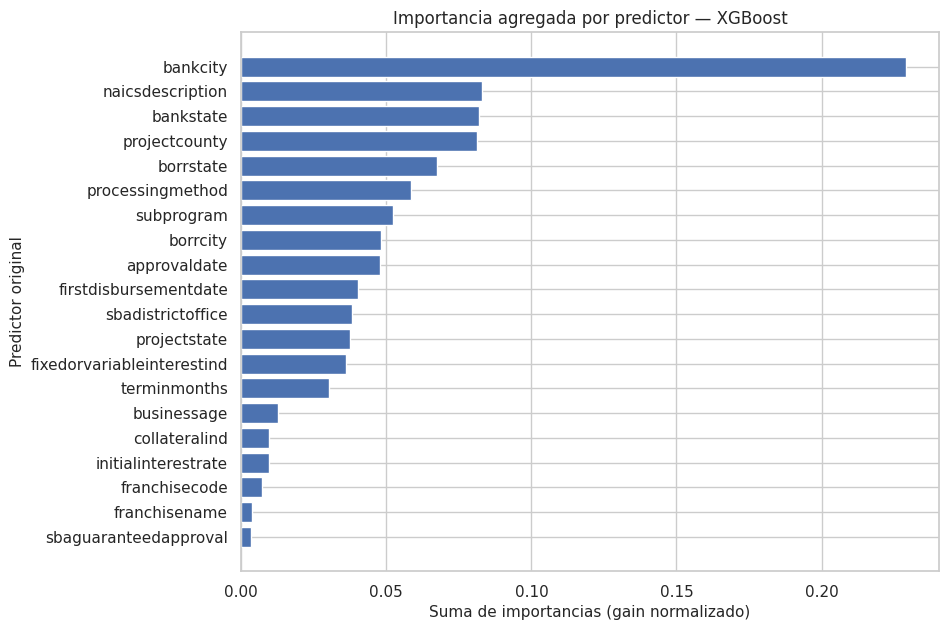

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_feature_importance_xgb_aggregated.png


In [30]:
# ============================================================
# 13.1b Importancia agregada por variable original (post-OHE)
#   - Suma importancias de dummies por variable categórica
# ============================================================

import re

imp_df = pd.read_csv(os.path.join(TABLE_DIR, "feature_importance_xgb.csv"))

def original_var(feat: str) -> str:
    # num__var
    if feat.startswith("num__"):
        return feat.replace("num__", "")
    # cat__var_level -> var
    if feat.startswith("cat__"):
        s = feat.replace("cat__", "")
        # toma todo antes del primer "_" (donde empieza el nivel)
        # OJO: si tu variable original tiene "_" esto lo partiría.
        # Ajuste: intenta detectar con lista de categóricas si existe.
        return s.split("_")[0]
    return feat

imp_df["variable"] = imp_df["feature"].apply(original_var)

agg = (imp_df.groupby("variable", as_index=False)["importance"]
       .sum()
       .sort_values("importance", ascending=False))

display(agg.head(30))

out_tbl = os.path.join(TABLE_DIR, "feature_importance_xgb_aggregated.csv")
agg.to_csv(out_tbl, index=False)
print("Guardado:", out_tbl)

# gráfico top 20 agregadas
topk = 20
plt.figure(figsize=(9,7))
plt.barh(
    agg.head(topk)["variable"][::-1],
    agg.head(topk)["importance"][::-1]
)
plt.title("Importancia agregada por predictor — XGBoost")
plt.xlabel("Suma de importancias (gain normalizado)")
plt.ylabel("Predictor original")
plt.grid(True)

out_fig = os.path.join(FIG_DIR, "fig_feature_importance_xgb_aggregated.png")
plt.savefig(out_fig, dpi=200, bbox_inches="tight")
plt.show()
print("Guardado:", out_fig)

Se incluyen variables temporales disponibles en originación; su alta importancia sugiere sensibilidad a régimen macroeconómico.

**Interpretabilidad (XGBoost)**

Se reporta la importancia de variables del modelo XGBoost entrenado sobre el conjunto BASE.
Dado que el preprocesamiento incluye codificación One-Hot para variables categóricas, la importancia se analiza en dos niveles:

Nivel post-preprocesamiento (dummies): identifica categorías específicas con alta contribución.

Nivel predictor original (agregado): se suma la importancia de todas las dummies pertenecientes a un mismo predictor, lo cual facilita la interpretación.

Hallazgos principales.
Las variables con mayor contribución corresponden principalmente a componentes geográficos y del originador (bankcity, bankstate, borrstate, projectcounty), lo cual sugiere heterogeneidad regional del riesgo y diferencias sistemáticas en patrones de originación. Adicionalmente, variables económicas/contractuales como initialinterestrate, terminmonths y fixedorvariableinterestind aparecen como predictores relevantes, consistentes con el riesgo crediticio.

Nota: la alta importancia de variables geográficas puede reflejar proxies de segmentación; se reporta como hallazgo empírico del dataset, no como relación causal.

## **14. Comparación final de modelos**

In [36]:
# ============================================================
# 14. Comparación final de modelos (BASE vs STRESS)
#     - Ranking final por desempeño en STRESS
# ============================================================

import os
import pandas as pd

final_compare = wide.copy()

# Renombrar columnas para que queden "bonitas" en la memoria
final_compare = final_compare.rename(columns={
    "model": "Modelo",
    "roc_auc_BASE (CV OOF)": "ROC-AUC BASE",
    "roc_auc_STRESS (post-COVID)": "ROC-AUC STRESS",
    "pr_auc_BASE (CV OOF)": "PR-AUC BASE",
    "pr_auc_STRESS (post-COVID)": "PR-AUC STRESS",
    "brier_BASE (CV OOF)": "Brier BASE",
    "brier_STRESS (post-COVID)": "Brier STRESS",
    "delta_roc_auc": "Δ ROC-AUC",
    "delta_pr_auc": "Δ PR-AUC",
    "delta_brier": "Δ Brier"
})

# Orden final por ROC-AUC en STRESS (criterio principal fuera de muestra)
final_compare = final_compare.sort_values("ROC-AUC STRESS", ascending=False)

display(final_compare)

# Guardar tabla lista para la memoria
out_path = os.path.join(TABLE_DIR, "tabla_final_comparacion_modelos_base_vs_stress.csv")
final_compare.to_csv(out_path, index=False)
print("Guardado:", out_path)

,Modelo,ROC-AUC BASE,ROC-AUC STRESS,PR-AUC BASE,PR-AUC STRESS,Brier BASE,Brier STRESS,Δ ROC-AUC,Δ PR-AUC,Δ Brier
2,XGBoost,0.974365,0.963172,0.788064,0.803023,0.029895,0.030606,-0.011193,0.014959,0.000711
1,TabNet,0.771976,0.906332,0.217604,0.488516,0.082591,0.051752,0.134356,0.270912,-0.030839
0,Regresión Logística,0.871028,0.835988,0.507359,0.281380,0.051216,0.069306,-0.035040,-0.225979,0.018090


Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/tables/tabla_final_comparacion_modelos_base_vs_stress.csv


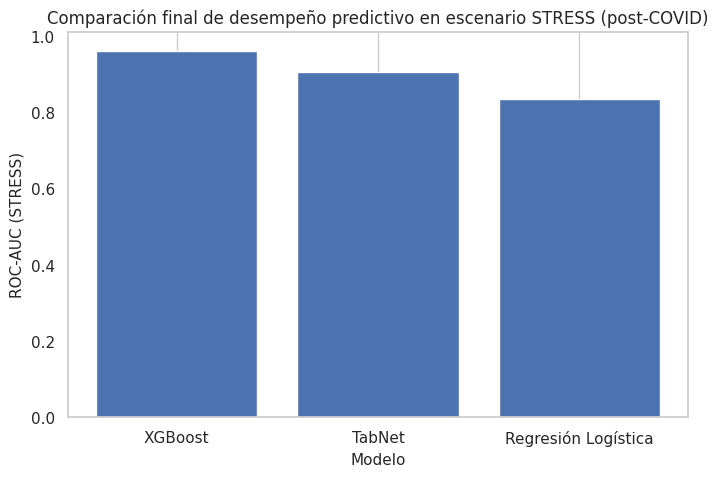

Guardado: /content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_ranking_final_modelos_stress.png


In [38]:
# ============================================================
# 14.b Figura final — Ranking por ROC-AUC STRESS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(final_compare["Modelo"], final_compare["ROC-AUC STRESS"])
plt.title("Comparación final de desempeño predictivo en escenario STRESS (post-COVID)")
plt.ylabel("ROC-AUC (STRESS)")
plt.xlabel("Modelo")
plt.grid(axis="y")

fig_path = os.path.join(FIG_DIR, "fig_ranking_final_modelos_stress.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Guardado:", fig_path)

**Hallazgos Principales:**
Para descartar dependencia espuria de identificadores del originador, se contrastó el rendimiento del modelo bajo un esquema de eliminación de variables tipo ID (bank* / borr*), observándose que el desempeño global se mantiene en rangos comparables, lo que sugiere que el modelo no depende exclusivamente de señales memorísticas.

## **14. Limitaciones del estudio**

A pesar de los resultados obtenidos, es importante reconocer algunas limitaciones del presente estudio que deben considerarse al interpretar los hallazgos.

En primer lugar, el análisis se basa exclusivamente en las variables disponibles en el dataset utilizado. Aunque el conjunto de datos incluye información relevante sobre características del préstamo, del prestatario y de la entidad originadora, la ausencia de variables financieras más detalladas o de indicadores macroeconómicos podría limitar la capacidad explicativa del modelo y su capacidad para capturar determinados factores estructurales del riesgo crediticio.

En segundo lugar, la elevada importancia observada en variables de carácter geográfico (por ejemplo, ciudad o estado del banco o del prestatario) puede reflejar patrones regionales presentes en el dataset o características específicas de las prácticas de originación de crédito. No obstante, estos resultados deben interpretarse como **asociaciones empíricas dentro del conjunto de datos analizado**, y no necesariamente como relaciones causales directas con la probabilidad de incumplimiento.

Adicionalmente, el análisis de robustez temporal se ha realizado considerando un único escenario de cambio de distribución asociado al periodo posterior a la crisis derivada de la pandemia de COVID-19. Aunque este enfoque permite evaluar la estabilidad del modelo ante un cambio macroeconómico relevante, otros escenarios de estrés o ciclos económicos diferentes podrían generar comportamientos distintos en los modelos evaluados.

Finalmente, el estudio se centra en la comparación de modelos supervisados aplicados a datos tabulares estructurados. Si bien este enfoque resulta adecuado para el problema analizado, investigaciones futuras podrían explorar extensiones metodológicas, como la incorporación de información macroeconómica externa, modelos híbridos que combinen aprendizaje automático con enfoques econométricos, o arquitecturas avanzadas de aprendizaje profundo específicamente diseñadas para datos tabulares.

## **15. Conclusiones**

El presente trabajo desarrolló un experimento de modelado de riesgo crediticio utilizando datos históricos de préstamos garantizados por la Small Business Administration (SBA), con el objetivo de comparar el desempeño de distintos enfoques de aprendizaje automático en la predicción de incumplimiento crediticio.

Para ello, se evaluaron tres modelos representativos aplicados a datos tabulares: **Regresión Logística**, **XGBoost** y **TabNet**. La comparación se realizó mediante un protocolo experimental homogéneo que incluyó validación cruzada estratificada sobre el periodo BASE (2010–2019), así como evaluación fuera de muestra temporal sobre el periodo STRESS (2020+), con el fin de analizar la robustez de los modelos frente a cambios en la distribución de los datos.

Los resultados obtenidos muestran una **superioridad consistente de XGBoost** frente a los demás modelos evaluados. En particular, el modelo alcanza el mejor desempeño en términos de:

- **capacidad discriminativa**, medida mediante ROC-AUC,
- **desempeño en eventos raros**, evaluado mediante PR-AUC,
- **calibración probabilística**, medida mediante Brier Score.

Posteriormente, el modelo seleccionado se entrenó utilizando la totalidad del conjunto BASE y se evaluó sobre el periodo STRESS (post-COVID), con el objetivo de analizar su comportamiento bajo cambio temporal de distribución. Los resultados muestran que el modelo mantiene un **desempeño estable fuera de muestra**, con una ligera reducción en la capacidad discriminativa y niveles comparables de calibración y precisión en eventos raros.

La Tabla siguiente resume el desempeño comparativo de los modelos en el escenario STRESS.

| Modelo | ROC-AUC BASE | ROC-AUC STRESS | PR-AUC STRESS | Brier STRESS |
|------|------|------|------|------|
| **XGBoost** | 0.974 | **0.963** | **0.803** | **0.030** |
| TabNet | 0.772 | 0.906 | 0.489 | 0.051 |
| Regresión Logística | 0.871 | 0.836 | 0.281 | 0.069 |

Los resultados evidencian que **XGBoost mantiene el mejor equilibrio entre discriminación, calibración y estabilidad temporal**, superando tanto al modelo lineal tradicional como al enfoque de aprendizaje profundo tabular evaluado.

En conjunto, estos hallazgos sugieren que XGBoost constituye una alternativa robusta para la modelización del riesgo de default en datasets tabulares de crédito, ofreciendo un compromiso favorable entre capacidad predictiva, estabilidad temporal e interpretabilidad.

En línea con la evidencia reportada en la literatura de aprendizaje automático tabular, los métodos de *gradient boosting* continúan mostrando un rendimiento muy competitivo frente a enfoques de *deep learning* en datasets estructurados de tamaño medio, lo que resulta coherente con el mejor desempeño observado para XGBoost en el presente estudio.

La **Figura X** muestra la comparación visual del desempeño discriminativo de los modelos en el escenario STRESS (post-COVID).


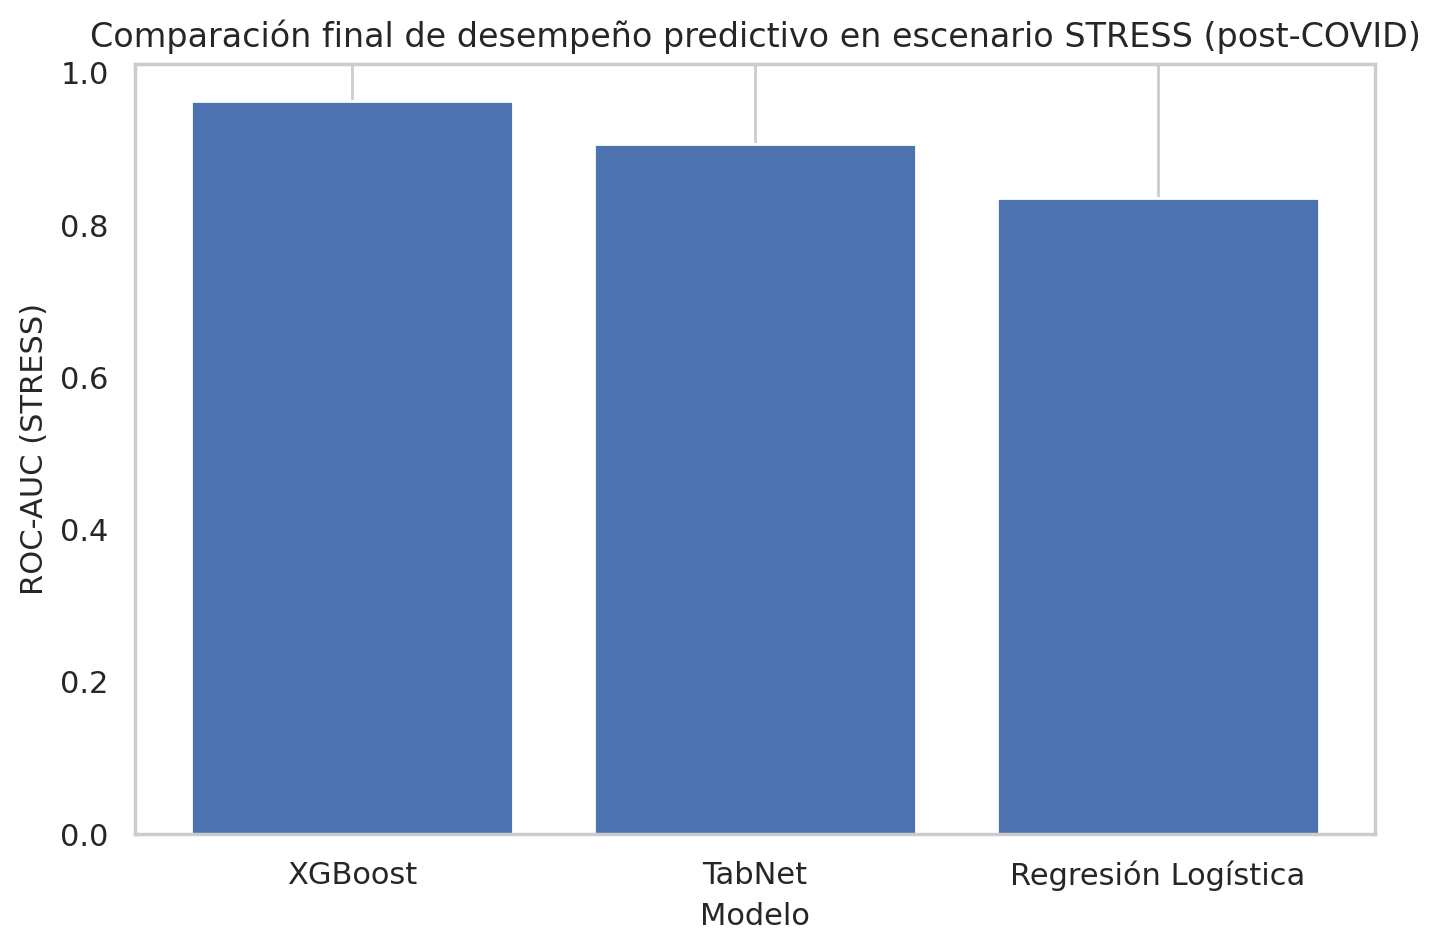

In [41]:
from IPython.display import Image, display

display(Image(filename="/content/drive/MyDrive/TFM-Scoring-crediticio/outputs/figures/fig_ranking_final_modelos_stress.png"))

In [51]:
import pandas as pd

print("Dataset size total:", len(df))
print("BASE size:", len(df_base))
print("STRESS size:", len(df_stress))

# 1) Candidatos típicos de target binario
candidates = ["default", "y", "target", "label", "is_default", "bad", "DEFAULT"]

target_col = None
for c in candidates:
    if c in df.columns:
        target_col = c
        break

# 2) Si no hay target binario, intentar con MIS_STATUS (muy común en SBA)
if target_col is None and "MIS_STATUS" in df.columns:
    # Considera default = CHGOFF (charge-off).
    default_rate = (df["MIS_STATUS"].astype(str).str.upper() == "CHGOFF").mean()
    print("Default rate (from MIS_STATUS == 'CHGOFF'):", round(float(default_rate), 6))

elif target_col is not None:
    # Si existe y es numérico/binario
    s = df[target_col]
    # Por si está como strings "0"/"1"
    s_num = pd.to_numeric(s, errors="coerce")
    if s_num.notna().mean() > 0.95:
        print(f"Default rate (from '{target_col}'):", round(float(s_num.mean()), 6))
    else:
        # Si es categórico, intenta mapear default = 1 / 'yes' / 'true'
        default_rate = s.astype(str).str.lower().isin(["1", "true", "yes", "default", "bad"]).mean()
        print(f"Default rate (heuristic from '{target_col}'):", round(float(default_rate), 6))

else:
    print("No pude inferir la columna objetivo. Columnas disponibles (top 30):")
    print(list(df.columns)[:30])

Dataset size total: 205487
BASE size: 205487
STRESS size: 61681
No pude inferir la columna objetivo. Columnas disponibles (top 30):
['y_true', 'p_hat']


## **Diagrama**

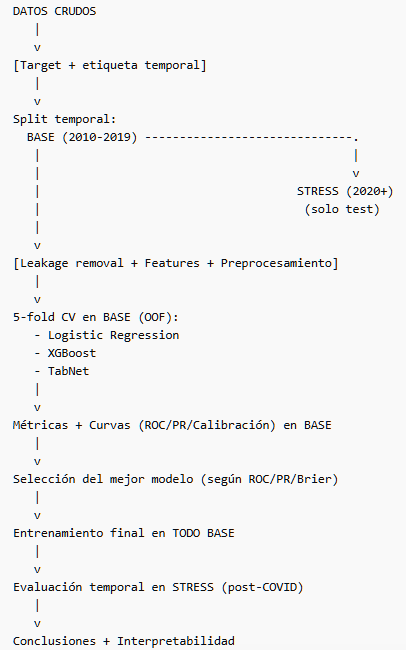

In [63]:
[v for v in globals().keys() if "oof" in v.lower()]

['oof_log', 'oof_xgb', 'oof_tabnet', 'oof']

In [65]:
[v for v in globals().keys() if "base" in v.lower()]

['df_base',
 'X_base',
 'y_base',
 'missing_base',
 'results_base',
 'base_metrics',
 'base_xgb',
 'roc_base',
 'pr_base',
 'brier_base',
 'X_base_tab',
 'y_base_tab',
 'get_base_row',
 'base_lr',
 'base_tab',
 'base_rows',
 'base_df',
 'cands_base']

In [58]:
[v for v in globals().keys() if "y" in v.lower()]

['get_ipython',
 'only_pre',
 'only_post',
 'summary',
 'y_base',
 'y_stress',
 'y_tr',
 'y_te',
 'suspect_keywords',
 'y_tab',
 'y',
 'keys',
 'y_base_tab',
 'y_stress_tab',
 'display',
 'y_stress_name']

In [59]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import brier_score_loss

print("=== STRESS ===")
print("XGBoost  ROC-AUC:", roc_auc_score(y_stress, p_stress))
print("LogReg   ROC-AUC:", roc_auc_score(y_stress, p_stress_lr))
print("TabNet   ROC-AUC:", roc_auc_score(y_stress, p_stress_tabnet))

print("XGBoost  PR-AUC :", average_precision_score(y_stress, p_stress))
print("LogReg   PR-AUC :", average_precision_score(y_stress, p_stress_lr))
print("TabNet   PR-AUC :", average_precision_score(y_stress, p_stress_tabnet))

print("XGBoost  Brier  :", brier_score_loss(y_stress, p_stress))
print("LogReg   Brier  :", brier_score_loss(y_stress, p_stress_lr))
print("TabNet   Brier  :", brier_score_loss(y_stress, p_stress_tabnet))

=== STRESS ===
XGBoost  ROC-AUC: 0.9631723168755498
LogReg   ROC-AUC: 0.8359875393726939
TabNet   ROC-AUC: 0.9063317373216526
XGBoost  PR-AUC : 0.803022500076084
LogReg   PR-AUC : 0.2813799608807941
TabNet   PR-AUC : 0.4885157551511456
XGBoost  Brier  : 0.03060582669605942
LogReg   Brier  : 0.06930642646517537
TabNet   Brier  : 0.051751659404928894


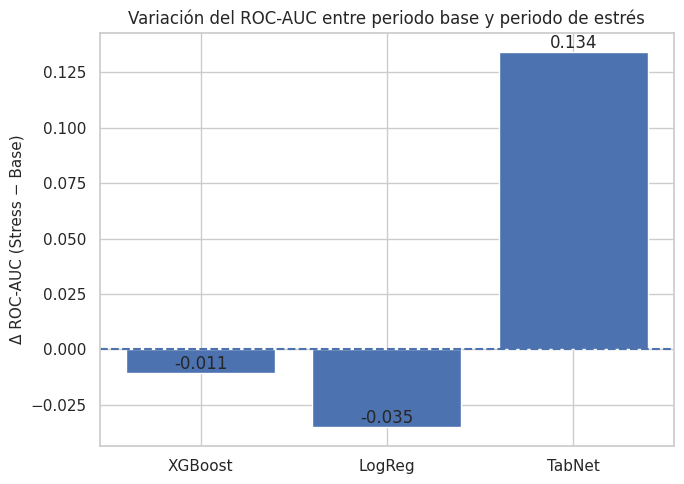

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Valores obtenidos en el experimento
models = ["XGBoost", "LogReg", "TabNet"]

auc_base = [0.974, 0.871, 0.772]
auc_stress = [0.9631723168755498, 0.8359875393726939, 0.9063317373216526]

# calcular diferencia
delta_auc = [s - b for s, b in zip(auc_stress, auc_base)]

plt.figure(figsize=(7,5))

bars = plt.bar(models, delta_auc)

plt.axhline(0, linestyle="--")

plt.ylabel("Δ ROC-AUC (Stress − Base)")
plt.title("Variación del ROC-AUC entre periodo base y periodo de estrés")

# mostrar valores en las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f"{yval:.3f}",
             ha='center', va='bottom')

plt.tight_layout()

# guardar imagen para el TFM
plt.savefig("figura_6_1_delta_auc.png", dpi=300)

plt.show()